(long_run_risk_operator)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 长期风险：一种算子方法

```{contents} 目录
:depth: 2
```

## 概述

标准的短视界资产定价告诉我们，均衡价格如何补偿投资者所承担的微小、瞬时的冲击暴露。

也就是说，它们告诉我们风险价格期限结构的*短端*。

但许多最有趣的资产定价问题（例如股权溢价之谜、收益率曲线的斜率、长期期权的价格）关注的是风险价格期限结构的*长端*。

本讲座使用 {cite:t}`HansenScheinkman2009` 的算子方法来研究长端。

处于核心地位的将是一个随机贴现因子过程和一个回报过程，它们在时间上是乘性的，即条件期望定义了一个以视界 $t$ 为指标的估值算子*半群*。

该半群的长视界行为由状态空间上的单一特征值问题所控制。

通过求解该特征值问题并选择适当的特征函数，我们可以将乘性泛函 $M_t$ 分解为三个具有经济意义的部分：一个确定性的指数趋势、一个改变概率测度的非负鞅，以及一个瞬态的依赖状态的成分。

具体而言，该分解具有如下形式

$$
    M_t
    =
    \exp(\rho t)\, \hat M_t\,
    \frac{\phi(X_0)}{\phi(X_t)},
$$ (eq:hs-factorization)

其中

* $\rho$ 是一个标量（**主特征值**），给出渐近的增长或衰减率，
* $\phi$ 是状态空间上一个严格正的**主特征函数**，捕捉对当前状态的长期依赖性，
* $\hat M$ 是一个用于改变概率测度的正鞅（**鞅成分**），以及
* $\phi(X_0)/\phi(X_t)$ 是一个瞬态成分，当扭曲过程收敛到其平稳分布时会消失。

在有限状态问题中，这恰好是一个正矩阵的佩龙-弗罗贝尼乌斯分解；在一般状态空间中，它是一个连续状态的对应物。

我们将把 {eq}`eq:hs-factorization` 称为与 $(\rho,\phi,\hat M)$ 相关联的**乘性分解**。

{cite:t}`AlvarezJermann2005` 对随机贴现因子应用了一个相关的永久-瞬态分解。

算子方法将该分解与一个显式的特征值问题联系起来。

```{seealso}
本讲座与讲座 {doc}`advanced:additive_functionals` 密切相关，后者在离散时间线性高斯设定中，对可加与乘性泛函研究了同类的永久-瞬态分解。

同时阅读这两篇讲座，是学习连续时间和离散时间中长期风险表示的一个好方法。
```

我们将逐步推导出 {eq}`eq:hs-factorization`，并用它在具体模型中计算长期风险价格。

本讲座的计划是：

1. 建立正乘性泛函 $M$（贴现因子、回报、随机增长）以及它们所生成的估值半群。

2. 引入半群的**生成元**，这是一个局部算子，其特征值问题控制着长期行为。

3. 找到主特征函数 $\phi$ 并推导出分解。

4. 详细研究两个例子：一个有限状态马尔可夫链（其中一切都归结为佩龙-弗罗贝尼乌斯理论）和一个仿射扩散模型（其中特征函数是指数-仿射的，我们能得到闭式公式）。

5. 使用该分解来计算长期风险价格，并将它们与适用于短视界资产定价的局部风险价格进行比较。

一个反复出现的主题是，对持久性状态变量的冲击会在局部风险价格与长期风险价格之间形成一个楔子。

产生这个楔子的机制正是长期风险模型（如 {cite:t}`Bansal_Yaron_2004`）产生大额股权溢价的途径。

我们从以下导入开始

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig, expm
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 乘性泛函

### 设定

设 $\{X_t : t \geq 0\}$ 是一个具有状态空间 $\mathcal D_0$ 的连续时间马尔可夫过程，并设 $\mathcal F_t$ 表示由其历史生成的过滤族。

我们将研究一个强马尔可夫过程，其样本路径是 càdlàg 的（定义如下）。

为了得到后面给出的显式公式，我们将专门讨论一个半鞅，它分解为一个连续成分 $X^c$ 和一个纯跳跃成分 $X^j$：

$$
    X_t = X_t^c + X_t^j .
$$

我们将连续成分的动态写为

$$
    dX_t^c = \xi(X_{t-})\, dt + \Gamma(X_{t-})\, dB_t,
$$

将纯跳跃成分写为

$$
    dX_t^j = \int \bigl(y - X_{t-}\bigr)\, \zeta(dy, dt),
$$

其中 $\zeta$ 是以*跳后状态* $y$ 为指标的跳跃随机计数测度，因此 $\zeta(B, [0,t])$ 计数了 $[0,t]$ 内落在博雷尔集 $B$ 中的跳跃次数。

其补偿子为 $\eta(dy \mid X_{t-})\, dt$，即 $X$ 从 $X_{t-}$ 跳入区域 $dy$ 的速率。

我们将在全文中使用这个 "$y$ = 跳后状态" 的约定，以匹配下面生成元中出现的 $\phi(y) - \phi(x)$ 形式。

我们还施加两个简化假设：

* 在有限时间区间上的**有限跳跃**：在任何有界区间上只发生有限次跳跃；这使得对跳跃测度的积分保持良定义且有限。
* $\Gamma$ 中的**充分秩**，使得与定价相关的布朗冲击可以从状态历史中恢复；这使得马尔可夫状态 $X$ "足够丰富" 以描述估值。

这些假设让我们能以闭式写出生成元，并自由地使用基于鞅的测度变换。

### 泛函与 càdlàg 路径

我们需要一个名称来表示 "一个记录关于 $X$ 历史某些信息的过程"。

例如，这包括随机贴现因子或累积回报。

```{prf:definition} 泛函
:label: lrr-def-functional

一个**泛函**是一个由 $X$ 的历史构造出的实值适应过程 $\{M_t : t \geq 0\}$，使得对每个 $t$，$M_t$ 关于 $\mathcal F_t$ 可测。
```

我们将始终使用泛函的 **càdlàg** 版本，这是法语缩写，意为 "右连续且有左极限"。

具体地，对几乎每条样本路径 $\omega$，

$$
    \lim_{s \downarrow t} M_s(\omega) = M_t(\omega)
    \qquad \text{对所有 } t \geq 0,
$$

并且左极限 $M_{t-}(\omega) := \lim_{s \uparrow t} M_s(\omega)$ 对所有 $t > 0$ 存在且有限。

因此，路径可以跳跃，但每次跳跃 $\Delta M_t := M_t - M_{t-}$ 瞬时发生。

在跳跃时刻 $t$，取值是跳后值，而非跳前值。

```{note}
为什么值得坚持要求 càdlàg 性质？

因为我们后面会想要 (i) 对泛函关于时间积分，(ii) 应用可选停止论证，以及 (iii) 取像 $\lim_{t \to \infty} t^{-1}\log M_t$ 这样的极限。

这三种操作都需要在 $(\omega,t)$ 中的联合可测性，而 càdlàg 路径自动为我们提供了这一点。
```

### 乘性

我们对泛函 $M$ 施加的核心限制是它在时间上是*乘性的*。

```{prf:definition} 乘性泛函
:label: lrr-def-multiplicative-functional

如果 $M_0 = 1$ 且

$$
    M_{t+u} = M_u(\theta_t)\, M_t ,
    \qquad t, u \geq 0,
$$ (eq:multiplicative)

则泛函 $\{M_t : t \geq 0\}$ 是**乘性的**，其中 $\theta_t$ 将底层马尔可夫路径向前平移 $t$ 个单位。
```

为什么这是一个有用的要求条件？

考虑 $M_t = S_t$，一个随机贴现因子。

日期 $0$ 时对日期 $t$ 收益 $\Pi_t$ 的估值是 $\mathbb{E}[S_t\Pi_t \mid \mathcal F_0]$。

如果我们改为在中间日期 $\tau$ 购买该收益，其日期 $\tau$ 的价格必然是

$$
    \mathbb{E}\left[\frac{S_t}{S_\tau}\Pi_t \,\Big|\, \mathcal F_\tau\right].
$$

为使价格只依赖于当前马尔可夫状态 $X_\tau$（而不依赖于直到 $\tau$ 的整个历史），比值 $S_t/S_\tau$ 必须只是 $\tau$ *之后*的马尔可夫路径的函数。

因此，$S_{\tau+u}/S_\tau = S_u(\theta_\tau)$，这恰好是 {eq}`eq:multiplicative`。

所以乘性正是一价定律的马尔可夫形式。

同样的结构性质随后被沿用到随机增长和累积回报。

### 可加泛函

处理一个严格正的乘性泛函的*对数*通常更容易。

如果 $M_t > 0$，我们可以写 $M_t = \exp(A_t)$，那么乘性性质 {eq}`eq:multiplicative` 就变成了 $A$ 的相应可加性质。

```{prf:definition} 可加泛函
:label: lrr-def-additive-functional

如果 $A_0 = 0$ 且

$$
    A_{t+u} = A_u(\theta_t) + A_t ,
$$

则泛函 $\{A_t : t \geq 0\}$ 是**可加的**。
```

因此，可加泛函的指数恰好是严格正的乘性泛函。

在我们的跳跃-扩散设定中，一个有用的参数化是

$$
    A_t
    =
    \int_0^t \beta(X_s)\, ds
    + \int_0^t \gamma(X_{s-})^\top dB_s
    + \sum_{0 \leq s \leq t} \kappa(X_s, X_{s-}) ,
$$ (eq:additive-functional)

其中三个函数 $(\beta, \gamma, \kappa)$ 扮演以下角色：

* $\beta(x)$ 是一个**依赖状态的漂移**率（例如，一个短期利率为 $r(x)$ 的纯贴现因子有 $\beta(x) = -r(x)$）。
* $\gamma(x)$ 是一个**布朗载荷**，控制布朗冲击在状态 $x$ 时如何馈入 $A$。
* $\kappa(y,x)$ 是一个**跳跃幅度**，每当 $X$ 从 $x$ 跳到 $y$ 时触发。

为使一切良定义，我们施加自然的可积性条件

$$
    \int_0^t |\beta(X_s)|\, ds < \infty,
    \qquad
    \int_0^t \|\gamma(X_s)\|^2\, ds < \infty,
$$

以及 $\kappa(x,x)=0$（如果状态不改变则无跳跃）和

$$
    \int \exp[\kappa(y,x)]\, \eta(dy \mid x) < \infty.
$$

这个参数化对本讲座中我们所做的一切都足够丰富，尽管可加泛函也可以包括占用时间之类的东西。

## 半群

一个乘性泛函 $M$ 连同马尔可夫过程 $X$ 为每个视界 $t$ 定义了一个**估值算子**：

$$
    \mathbb M_t \psi(x) = \mathbb{E}\left[M_t \psi(X_t) \mid X_0 = x\right] .
$$

你应当将 $\mathbb M_t \psi(x)$ 理解为 "从状态 $x$ 出发，日期 $t$ 收益 $\psi(X_t)$ 在日期 $0$ 的估值"，用 $M_t$ 加权。

算子族 $\{\mathbb M_t\}_{t \geq 0}$ 具有一个关键的复合结构，即*半群性质*。

```{prf:definition} 单参数半群
:label: lrr-def-one-parameter-semigroup

如果 $T_0=I$ 且对所有 $s,t \geq 0$ 有 $T_{t+s}=T_tT_s$，则线性算子族 $\{T_t : t \geq 0\}$ 是一个**单参数半群**。

如果每当 $\psi \geq 0$ 时 $T_t\psi \geq 0$，则它是**正的**。
```

```{prf:definition} 乘性半群
:label: lrr-def-multiplicative-semigroup

给定一个乘性泛函 $M$，相关联的**乘性半群**是算子族

$$
    \mathbb M_t \psi(x)
    =
    \mathbb{E}\left[M_t \psi(X_t) \mid X_0 = x\right].
$$ (eq:m-semigroup)
```

半群恒等式 $\mathbb M_{t+u} = \mathbb M_t \mathbb M_u$ 由迭代期望和 $M$ 的乘性性质得出。

从经济学上讲，这是*马尔可夫迭代估值律*：为了在今天对日期 $(t+u)$ 的收益估值，我们可以

* 直接从 $t+u$ 一步贴现回 $0$（应用 $\mathbb M_{t+u}$），或者
* 先从 $t+u$ 贴现回 $t$（应用 $\mathbb M_u$），然后将得到的日期 $t$ 价格贴现回 $0$（应用 $\mathbb M_t$）。

半群恒等式表明这两个过程给出相同的答案。

这是排除跨视界套利的跨期一致性的算子层面版本。

下面将经常出现四个正乘性泛函。

| 符号 | 对象 | 半群 |
|:---|:---|:---:|
| $S$ | 随机贴现因子 | $\{\mathbb S_t\}$ |
| $V$ | 资产的累积回报 | $\{\mathbb V_t\}$ |
| $G$ | 现金流的随机增长 | $\{\mathbb G_t\}$ |
| $Q=GS$ | 增长现金流的估值 | $\{\mathbb Q_t\}$ |

前三个是基本要素。

第四个结合了贴现和增长，用于对随时间随机增长的现金流估值。

```{prf:definition} 随机贴现因子
:label: lrr-def-stochastic-discount-factor

一个**随机贴现因子** $S$ 是一个正乘性泛函，对它而言 $\mathbb{E}[S_t Z_t \mid X_0=x]$ 是一个 $\mathcal F_t$-可测收益 $Z_t$ 在日期 $0$ 的估值。
```

```{prf:definition} 估值泛函
:label: lrr-def-valuation-functional

给定一个随机贴现因子 $S$，一个**估值泛函** $V$ 是一个正乘性泛函，使得 $\{V_t S_t : t \geq 0\}$ 是一个鞅。
```

```{prf:definition} 随机增长泛函
:label: lrr-def-stochastic-growth-functional

一个**随机增长泛函** $G$ 是一个正乘性泛函，解释为应用于日期 $0$ 现金流的乘性增长因子。
```

考虑一个现金流 $D_t = D_0\, G_t\, \psi(X_t)$，其中 $D_0 > 0$ 是日期 $0$ 的水平，$\psi$ 是一个博雷尔状态-收益函数。

用 $S$ 贴现并用 $G$ 增长，其日期 $0$ 的估值为

$$
    D_0\, \mathbb Q_t \psi(X_0),
    \qquad
    \mathbb Q_t \psi(x)
    =
    \mathbb{E}\left[G_t S_t \psi(X_t) \mid X_0=x\right].
$$

```{prf:definition} 现金流估值半群
:label: lrr-def-cash-flow-valuation-semigroup

**现金流估值半群**是由 $Q=GS$ 生成的乘性半群。
```

$\mathbb Q_t$ 的长视界行为是本讲座的核心对象：它告诉我们当前价格如何对未来遥远时点上实现的现金流增长风险进行估值。

```{note}
分解 $D_t=D_0 G_t \psi(X_t)$ 不是唯一的。

对任何正函数 $\varphi$，

$$
    D_t
    =
    D_0
    \left[G_t\frac{\varphi(X_t)}{\varphi(X_0)}\right]
    \left[\frac{\psi(X_t)\varphi(X_0)}{\varphi(X_t)}\right],
$$

因此可以在 $G$ 和 $\psi$ 之间转移一个瞬态的依赖状态的因子而不改变 $D_t$。

我们通过归一化增长成分使其永久部分是一个鞅来解决这种不确定性：$G_t = \exp(\delta t)\hat G_t$，其中 $\hat G$ 是一个鞅，$\delta$ 是一个常数趋势。

下面的特征函数构造将准确告诉我们应选取哪个鞅。
```

### 局部定价约束

在处理长视界之前，最好先理解*短端*的估值。

这就是标准的瞬时风险-回报关系。

这将给我们一个基准，用于与长期风险价格进行比较。

关于同样基于 SDF 的资产定价思想的教科书离散时间处理，见 {doc}`advanced:asset_pricing_lph`。

关于基于欧拉方程的资产定价的估计视角，见 {doc}`hansen_singleton_1982`。

关键的出发点是，一个估值泛函 $V$ 必须满足无套利要求，即 $VS$ 是一个鞅（{prf:ref}`lrr-def-valuation-functional`）。

我们将随机贴现因子 $S$ 和估值泛函 $V$ 参数化为可加泛函，系数分别为 $(\beta^s,\gamma^s,\kappa^s)$ 和 $(\beta^v,\gamma^v,\kappa^v)$，采用 {eq}`eq:additive-functional` 的记号。

对于一个具有参数 $(\beta,\gamma,\kappa)$ 的一般正乘性泛函 $M = \exp(A)$，将伊藤公式应用于 $\exp(A_t)$ 并要求 $dM_t/M_{t-}$ 的漂移消失，得到**局部鞅约束**：

$$
    \beta(x)
    + \frac{\gamma(x)^\top\gamma(x)}{2}
    + \int \big(\exp[\kappa(y,x)] - 1\big)\, \eta(dy \mid x)
    = 0 .
$$ (eq:local-martingale-restriction)

这三项对应于：

* $A$ 本身的漂移，
* 来自布朗部分的伊藤修正（因为 $M = e^A$ 引入了一个二次变差贡献），以及
* $M$ 在乘子 $\exp[\kappa(y,x)]$ 处的被补偿跳跃。

我们请你在 {ref}`lrr_ex_local_mg` 中验证这一点。

将其应用于 $VS$（其参数相加：$(\beta^v + \beta^s, \gamma^v + \gamma^s, \kappa^v + \kappa^s)$），得到**局部定价约束**

$$
    \beta^v+\beta^s
    =
    -\frac{\|\gamma^v+\gamma^s\|^2}{2}
    -
    \int
        \left(
            \exp[\kappa^v(y,\cdot)+\kappa^s(y,\cdot)]-1
        \right)
        \eta(dy \mid \cdot).
$$ (eq:local-pricing-restriction)

这根据任何候选估值泛函的布朗和跳跃暴露确定了它的漂移 $\beta^v$。

为将其转化为*期望回报*，注意 $V$ 上的期望净回报率为

$$
    \epsilon^v
    =
    \beta^v
    + \frac{\|\gamma^v\|^2}{2}
    + \int
        \left(\exp[\kappa^v(y,\cdot)]-1\right)
        \eta(dy \mid \cdot) .
$$

与 {eq}`eq:local-pricing-restriction` 结合给出

$$
\begin{aligned}
    \epsilon^v
    &=
    -\beta^s
    - \gamma^v \cdot \gamma^s
    - \frac{\|\gamma^s\|^2}{2}
    \\
    &\quad
    -
    \int
        \left(
            \exp[\kappa^v(y,\cdot)+\kappa^s(y,\cdot)]
            -
            \exp[\kappa^v(y,\cdot)]
        \right)
        \eta(dy \mid \cdot).
\end{aligned}
$$ (eq:local-risk-return)

因此，布朗局部风险价格向量是 $-\gamma^s(x)$，用与 $\gamma^v(x)$ 相同的暴露单位表示。

跳跃风险通过函数 $\kappa^s$ 定价。

这个局部关系是风险价格期限结构的一端。

下面的特征值计算描述了另一端。

## 生成元

到目前为止，我们有一个算子族 $\{\mathbb M_t\}_{t \geq 0}$，每个视界 $t$ 对应一个。

这比我们能直接使用的信息要多。

我们所关心的是长期行为：当 $t \to \infty$ 时 $\mathbb M_t \psi$ 如何增长。

**生成元** $\mathbb A$ 将整个半群压缩成状态空间上的一个不依赖时间的算子。

它记录 $M_t \psi(X_t)$ 的*瞬时*变化率，其特征值驱动着 $\mathbb M_t$ 的长期增长率。

这让我们能将关于一个算子族的渐近问题转化为一个单一的特征值问题。

### 离散时间直觉

当时间为离散时，生成元的作用最容易看到，因此我们先在那里构建图景，然后再将其沿用。

设 $X_n$ 为马尔可夫过程，$M_n$ 为乘性泛函，并定义单期估值算子

$$
    K\psi(x)
    =
    \mathbb{E}\left[M_1 \psi(X_1) \mid X_0=x\right].
$$

迭代给出 $n$-期算子 $K^n$。

这类似于转移矩阵的逻辑：正如 $P^n$ 给出 $n$-步概率，$K^n$ 对 $n$-期收益加权，每一步都折叠进了 $M_1$。

所以一个局部对象 $K$ 控制着整个以视界为指标的族。

它也控制长期增长：如果 $K\phi = \lambda \phi$，那么

$$
    K^n \phi = \lambda^n \phi ,
$$

所以 $\lambda$ 是长期几何增长（或衰减）率，$\phi$ 是对当前状态的长期依赖性。

同样的算子给出加权收益的可预测变化率。

由乘性，

$$
    \mathbb{E}\left[
        M_{n+1}\psi(X_{n+1}) - M_n \psi(X_n)
        \mid \mathcal F_n
    \right]
    =
    M_n (K\psi - \psi)(X_n) ,
$$

所以从总变化中减去累积的可预测变化后剩下一个鞅：

$$
    M_n\psi(X_n)
    - \psi(X_0)
    - \sum_{j=0}^{n-1} M_j (K\psi - \psi)(X_j) .
$$

这里 $K-I$ 是 $M_n \psi(X_n)$ 的*局部*变化率，通过 $K^n$ 它也控制长期增长。

### 从离散时间到连续时间

连续时间保持同样的逻辑。

$K-I$ 的自然对应物是半群 $\{\mathbb M_t\}$ 的**无穷小生成元**，即在零处的时间导数：

$$
    \mathbb A \psi(x)
    :=
    \lim_{h \downarrow 0}
    \frac{\mathbb M_h \psi(x) - \psi(x)}{h},
$$

因此对小的 $h>0$，

$$
    \mathbb M_h \psi(x)
    \approx
    \psi(x) + h\, \mathbb A \psi(x) .
$$

```{note}
当 $M \equiv 1$ 时，乘性半群约化为标准的马尔可夫转移半群 $\mathbb M_t \psi(x) = \mathbb{E}[\psi(X_t) \mid X_0=x]$，而 $\mathbb A$ 变为教科书随机微积分中 $X$ 的熟悉的无穷小生成元 $\mathcal L$。

对于一般的 $M$，$\mathbb A$ 是同类型的对象，但它带有额外的项，用于编码 $M$ 的瞬时 "收益率"：贴现率、布朗风险价格、跳跃乘子。

这正是我们在下面 {eq}`eq:extended-generator` 中写出其闭式时将看到的。
```

为什么这是正确的对象？

如果 $\mathbb A\phi = \rho\phi$，那么候选

$$
    \hat M_t := \exp(-\rho t)\, M_t\, \frac{\phi(X_t)}{\phi(X_0)}
$$

自动是一个*局部*鞅。

当 $\hat M$ 实际上是一个鞅时（这是 {cite:t}`HansenScheinkman2009` 中假设 6.1 的内容），取期望给出 $K^n\phi = \lambda^n\phi$ 的连续时间类比：

$$
    \mathbb M_t \phi = \exp(\rho t)\, \phi .
$$

没有这个升级，我们只能得到上鞅不等式 $\mathbb M_t \phi \le \exp(\rho t)\, \phi$，我们将在下面重新讨论它。

因此 $\mathbb M_t$ 的长期行为被编码在局部算子 $\mathbb A$ 的一个特征值问题中，连同 $\hat M$ 的鞅性质。

### 扩展生成元

上面的极限定义需要一个限定条件。

为了使极限 $h \downarrow 0$ 严格化，教科书定义要求 $(\mathbb M_h\psi - \psi)/h$ 在选定的范数中收敛到 $\mathbb A\psi$，通常是有界连续函数上的一致收敛，此处半群是一个压缩。

但我们最关心的函数是求解 $\mathbb A\phi = \rho\phi$ 的主特征函数 $\phi$，而这些函数通常随状态 $X$ 而*增长*（在仿射-高斯基准中，$\phi$ 关于 $x$ 是指数-仿射的）。

所以它们不属于这个空间，极限对它们不一定收敛。

{cite:t}`HansenScheinkman2009` 通过用 $M_t \psi(X_t)$ 的一个 *Doob-Meyer 风格* 半鞅分解来刻画 $\mathbb A$，从而绕开了这一点，这是一个不需要任何范数的逐路径条件。

这是在离散时间中将 $K - I$ 写为 $M_n\psi(X_n)$ 的可预测变化率的连续时间对应物。

由此得到的**扩展生成元**允许无界的 $\psi$，具有比教科书生成元严格更大的定义域，并且在两者都有定义之处与之一致。

具体地：

```{prf:definition} 扩展生成元
:label: lrr-def-extended-generator

固定一个博雷尔函数 $\psi$，并寻找第二个博雷尔函数 $\chi$，它将扮演 "$M_t \psi(X_t)$ 在当前状态处的瞬时变化率" 的角色。我们询问是否存在 $\chi$ 使得

$$
    N_t
    =
    M_t \psi(X_t)
    - \psi(X_0)
    - \int_0^t M_s \chi(X_s)\, ds
$$

是一个局部鞅。

我们于是称 $\psi$ 属于 $M$ 的**扩展生成元** $\mathbb A$ 的定义域，并*定义*该算子为

$$
\mathbb A \psi := \chi.
$$

```

这三项扮演与离散时间中相同的角色：

* $M_t \psi(X_t) - \psi(X_0)$ 是加权收益在 $[0, t]$ 上的总变化，
* $\int_0^t M_s \chi(X_s)\, ds$ 沿路径累积期望变化率，
* $N_t$ 是残差。

要求 $N_t$ 是一个局部鞅，就确定了 $\chi = \mathbb A\psi$ 为 $M_t \psi(X_t)$ 在当前状态处的瞬时期望变化率。

* 当 $M \equiv 1$ 时，该定义约化为标准马尔可夫生成元的 Dynkin 公式
  $\mathcal L \psi(x)
  = \lim_{t \downarrow 0} t^{-1}\bigl[\mathbb{E}\psi(X_t) - \psi(x)\bigr]$。

* 当 $X$ 是一个跳跃扩散时，将伊藤公式应用于 $M_t\psi(X_t)$ 产生下面 {eq}`eq:extended-generator` 中 $\mathbb A\psi$ 的闭式表达式。

### 跳跃扩散的闭式

对于上面引入的跳跃-扩散设定，我们可以通过将伊藤公式应用于 $M_t\phi(X_t)$ 来显式计算 $\mathbb A$。

假设 $X$ 的连续部分满足

$$
    dX_t^c = \xi(X_t)dt + \Gamma(X_t)dB_t
$$

具有扩散矩阵 $\Sigma = \Gamma \Gamma^\top$，并设 $\eta(dy \mid x)$ 表示跳跃补偿子。

如果 $M=\exp(A)$ 按 {eq}`eq:additive-functional` 由 $(\beta,\gamma,\kappa)$ 参数化，那么对于光滑的 $\phi$，

$$
\begin{aligned}
\mathbb A \phi(x)
&=
\left[\xi(x)+\Gamma(x)\gamma(x)\right]^\top
    \frac{\partial \phi(x)}{\partial x}
\\
&\quad
+ \frac{1}{2}
  \operatorname{trace}\left[
    \Sigma(x)
    \frac{\partial^2\phi(x)}{\partial x \partial x^\top}
  \right]
\\
&\quad
+ \int
    [\phi(y)-\phi(x)]
    \exp[\kappa(y,x)] \eta(dy \mid x)
\\
&\quad
+ \left[
    \beta(x)
    + \frac{\gamma(x)^\top \gamma(x)}{2}
    + \int
        \left(\exp[\kappa(y,x)]-1\right)\eta(dy \mid x)
  \right]\phi(x).
\end{aligned}
$$ (eq:extended-generator)

这四项有透明的解释：

1. 第一项是标准马尔可夫漂移，被 $\Gamma\gamma$ 修正，这是驱动 $X$ 的布朗冲击与驱动 $M$ 的布朗冲击之间的一个*协方差修正*。
2. 第二项是标准扩散（伊藤）项。
3. 第三项将 $\phi$ 对跳跃-被补偿的转移率积分，由跳跃乘子 $\exp[\kappa(y,x)]$ 重新加权。
4. 第四项是一个乘性的*类收益率*项，它乘以 $\phi(x)$ 本身，并结合了 $M$ 的漂移、布朗伊藤修正和被补偿跳跃。

```{note}
当 $M=S$ 是一个随机贴现因子时，局部风险价格分散在生成元的四个部分中，而不是集中在水平项中。

* 布朗因子价格通过第一行中的漂移修正 $\xi \to \xi + \Gamma\gamma$ 进入。
* 跳跃风险价格通过第三行中的倾斜跳跃测度 $\eta \to \exp[\kappa]\,\eta$ 进入。
* 第四行中的水平项包含瞬时无风险利率成分（期限结构的*短端*）加上跳跃-补偿子贡献 $\int(\exp[\kappa]-1)\,\eta$。

我们请读者在 {ref}`lrr_ex4` 中验证 {eq}`eq:extended-generator` 的推导。
```

我们将在下面的仿射-扩散例子中直接应用这个公式。

## 主特征函数

我们现在来到本讲座的核心技术问题：

> 在估值半群下，哪些正收益以恒定的比例率增长？

当答案存在时，它是生成元的一个正特征函数。

```{prf:definition} 扩展生成元的特征函数
:label: lrr-def-generator-eigenfunction

如果

$$
    \mathbb A \phi = \rho \phi ,
$$ (eq:generator-eigen)

则博雷尔函数 $\phi$ 是 $\mathbb A$ 的一个**特征函数**，特征值为 $\rho$。

一个**主特征函数**是一个在状态空间上严格正的特征函数 $\phi$：对所有 $x \in \mathcal D_0$ 有 $\phi(x) > 0$。
```

严格正性要求很重要，因为 $\phi$ 将始终出现在分母中：除以它必须是安全的。

### 从特征函数到分解

为什么 $\mathbb A$ 的一个特征函数会给我们乘性分解 {eq}`eq:hs-factorization`？

离散时间类比指明了方向。如果 $K\phi = \lambda\phi$，那么

$$
    \lambda^{-n}\, M_n\, \frac{\phi(X_n)}{\phi(X_0)}
$$

是一个鞅：特征值方程恰好吸收了 $M_n\phi(X_n)$ 的单步漂移。

在连续时间中，$\lambda^n$ 变为 $\exp(\rho t)$，候选鞅是

$$
    \hat M_t
    =
    \exp(-\rho t)\, M_t\, \frac{\phi(X_t)}{\phi(X_0)} .
$$ (eq:mhat)

让我们检查 $\hat M$ 确实是一个局部鞅。

根据 $\mathbb A$ 的定义，半鞅 $Z_t := M_t\phi(X_t)$ 允许分解

$$
    dZ_t = M_t\, \mathbb A\phi(X_t)\, dt + dN_t ,
$$

其中 $N$ 是一个局部鞅。

特征值方程 $\mathbb A\phi = \rho\phi$ 将漂移替换为 $\rho Z_t\, dt$，分部积分给出

$$
    d\bigl(\exp(-\rho t) Z_t\bigr)
    = \exp(-\rho t)\,\bigl[dZ_t - \rho Z_t\, dt\bigr]
    = \exp(-\rho t)\, dN_t .
$$

因此 $\exp(-\rho t) Z_t$ 是一个局部鞅，除以 $\phi(X_0)$ 表明 $\hat M$ 也是如此。

将 {eq}`eq:mhat` 关于 $M_t$ 重新排列可恢复分解 {eq}`eq:hs-factorization`，其中 $\hat M$ 扮演鞅成分的角色。

```{prf:definition} 鞅成分与扭曲测度
:label: lrr-def-martingale-component

当 $\hat M$ 是一个鞅（而不仅仅是一个局部鞅）时，它是与 $(\rho,\phi)$ 相关联的**鞅成分**，并通过用 $\hat M_t$ 对日期 $t$ 事件加权定义**扭曲概率测度**：

$$
    \widehat{\Pr}(F \mid X_0=x)
    =
    \mathbb{E}[\hat M_t \mathbf 1_F \mid X_0=x],
    \qquad F \in \mathcal F_t.
$$
```

上述验证仅确立 $\hat M$ 是一个*局部*鞅，但上面的定义（以及 $\hat M$ 的测度变换解释）要求它是一个鞅。

我们通过采用 {cite:t}`HansenScheinkman2009` 的假设 6.1 来弥补这个缺口：

> {eq}`eq:mhat` 中定义的局部鞅 $\hat M$ 是一个鞅，即对每个 $t \geq 0$ 和 $x$ 有 $\mathbb{E}[\hat M_t \mid X_0 = x] = 1$。

我们从此以后一直采用这个假设。

即使不弥补这个缺口，我们仍然得到单侧控制。

由于 $\hat M$ 是非负的且 $\hat M_0 = 1$，它是一个上鞅，所以 $\mathbb{E}[\hat M_t \mid X_0=x] \leq 1$。

在 {eq}`eq:mhat` 中取期望，

$$
    \mathbb M_t \phi(x) \leq \exp(\rho t)\, \phi(x) ,
$$

所以 $\rho$ 至少是 $\mathbb M_t \phi$ 长期增长率的一个上界。

当 $\hat M$ 实际上是一个鞅时，$\mathbb{E}[\hat M_t] = 1$，不等式变为等式，局部条件 $\mathbb A\phi = \rho\phi$ 提升为半群特征值方程

$$
    \mathbb M_t \phi = \exp(\rho t)\, \phi,
    \qquad t \geq 0.
$$ (eq:semigroup-eigen)

### 扭曲过程的稳定性

我们现在有了对*任意*主特征函数的分解 {eq}`eq:hs-factorization`。

但要使 $(\rho,\phi)$ 描述 $\mathbb M_t$ 的**长期**行为，扭曲过程必须在 $t \to \infty$ 时收敛到一个平稳状态。

如果不这样，瞬态因子 $\phi(X_0)/\phi(X_t)$ 将不会消失，我们就无法仅从 $\rho$ 读出渐近行为。

我们需要三个条件，每个都排除了扭曲过程无法稳定下来的一种特定方式。

设 $\hat E$ 和 $\widehat{\Pr}$ 表示扭曲测度下的期望和概率，并设 $\hat{\mathbb A}$ 为该测度下 $X$ 的生成元。

*条件 1：存在一个平稳分布。*

```{prf:definition} 扭曲过程的平稳分布
:label: lrr-def-stationary-distribution

如果对 $\hat{\mathbb A}$ 的 $L^\infty$ 定义域中的每个 $\psi$，

$$
    \int \hat{\mathbb A}\psi\, d\hat\varsigma = 0
$$

则 $\mathcal D_0$ 上的概率测度 $\hat\varsigma$ 是扭曲过程的一个**平稳分布**。
```

$\hat\varsigma$ 是候选的长期分布。

没有它，扭曲过程就没有稳态，长期极限就无法表示为状态空间积分。

*条件 2：每个重要区域都可达。*

```{prf:definition} 不可约骨架
:label: lrr-def-irreducible-skeleton

如果存在 $\Delta > 0$，使得对每个满足 $\hat\varsigma(\Lambda) > 0$ 的博雷尔集 $\Lambda \subseteq \mathcal D_0$，

$$
    \hat E\!\left[
        \sum_{j=0}^\infty \mathbf 1_{\{X_{\Delta j} \in \Lambda\}}
        \,\bigg|\, X_0 = x
    \right] > 0
    \qquad \text{对所有 } x \in \mathcal D_0 ,
$$

则离散采样骨架 $\{X_{\Delta j} : j = 0, 1, \ldots\}$ 相对于 $\hat\varsigma$ 是**不可约的**。
```

没有它，长期分布可能依赖于起始状态；不同的吸引域会给出不同的极限。

*条件 3：每个重要区域都被无穷次访问。*

```{prf:definition} 哈里斯常返
:label: lrr-def-harris-recurrence

如果对每个满足 $\hat\varsigma(\Lambda) > 0$ 的博雷尔集 $\Lambda \subseteq \mathcal D_0$，

$$
    \widehat{\Pr}\!\left\{
        \int_0^\infty \mathbf 1_{\{X_t \in \Lambda\}}\, dt = \infty
        \,\bigg|\, X_0 = x
    \right\} = 1
    \qquad \text{对所有 } x \in \mathcal D_0 ,
$$

则过程 $X$ 在扭曲测度下是**哈里斯常返的**。
```

可达性（条件 2）是不够的。

一个集合可能是可达的，但以趋于零的概率被访问，因此时间平均无法收敛到 $\hat\varsigma$-平均。

哈里斯常返是有限链中 "常返状态" 的连续状态对应物。

收集这三个条件：

```{prf:definition} 随机稳定的扭曲过程
:label: lrr-def-stochastic-stability

如果 $\hat M$-扭曲的马尔可夫过程有一个平稳分布 $\hat\varsigma$，骨架 $\{X_{\Delta j}\}$ 相对于 $\hat\varsigma$ 是不可约的，且 $X$ 在扭曲测度下是哈里斯常返的，则它是**随机稳定的**。
```

### 长期近似

在 $\hat M$ 的鞅条件、$M$ 的严格正性以及随机稳定性下，长期极限取一个简洁的形式：

$$
    \lim_{t \to \infty}
    \exp(-\rho t)\, \mathbb M_t \psi
    =
    \phi
    \int \frac{\psi}{\phi}\, d\hat\varsigma .
$$ (eq:long-run-limit)

如下解读它：

* 因子 $\exp(\rho t)$ 捕捉半群的指数增长或衰减；一旦我们将其除去，剩下的部分有一个有限极限。
* 该极限中的状态依赖性*完全*由 $\phi(x)$ 捕捉。
* 标量 $\int (\psi/\phi)\, d\hat\varsigma$ 是收益 $\psi$ 的**长期强度**，用 $1/\phi$ 加权并对扭曲平稳分布取平均。

{cite:t}`HansenScheinkman2009` 命题 7.1 的两个精确情形是：

* **采样网格，$\hat\varsigma$-几乎每个起始状态。** 固定任意 $\Delta>0$ 并假设 $\int |\psi|/\phi\, d\hat\varsigma < \infty$；那么该极限对 $\hat\varsigma$-几乎每个 $x \in \mathcal D_0$ 沿 $t = \Delta j$ 成立。
* **连续 $t$，每个起始状态。** 如果 $\psi/\phi$ 是有界的，那么该极限对每个 $x \in \mathcal D_0$ 和每个 $t \to \infty$ 成立，无需对 $\psi$ 作连续性假设。

```{note}
$\mathbb A$ 可能有不止一个正特征函数使得相关联的 $\hat M$ 是一个鞅，可能有不同的特征值。

随机稳定性挑选出一个特定的。

根据 {cite:t}`HansenScheinkman2009` 命题 7.2，稳定特征函数的特征值 $\rho$ 是所有满足所维持条件的、允许严格正特征函数的 $\mathbb A$ 特征值中**最小**的。

任何共享此 $\rho$ 的其他正特征函数在 $\hat\varsigma$-几乎必然意义下与 $\phi$ 成比例。

下面的有限状态部分用更熟悉的佩龙-弗罗贝尼乌斯语言陈述了同样的选择，称 $\rho$ 为 $A$ 所有特征值中实部*最大*的特征值。

这两种描述识别出同一个特征值，因为在不可约有限状态情形中，$A$ 只有一个特征值允许严格正的特征向量。

在下面的仿射例子中，这两个集合分开了，因为二次方程 {eq}`eq:cf-roots` 有两个根 $c_f$，它们都给出具有不同特征值的严格正指数-仿射特征函数。

随机稳定性通过拒绝产生爆炸性扭曲过程的那个根，挑选出较小的 $\rho$。
```

## 一个有限状态马尔可夫链

我们现在将该框架应用于一个具体的例子。

我们从最简单的情形开始：一个有限状态马尔可夫链。

关于离散时间有限马尔可夫链的背景，见 {doc}`finite_markov`。

关于激发此处构造的有限状态链的资产定价应用，见 {doc}`markov_asset`。

这里，每个抽象对象都坍缩为一个熟悉的对象：

| 抽象对象 | 有限状态版本 |
|:---|:---|
| 马尔可夫过程 $X$ | 具有强度矩阵 $U$ 的连续时间链 |
| 生成元 $\mathbb A$ | 一个矩阵 $A$ |
| 半群 $\mathbb M_t$ | 矩阵指数 $\exp(tA)$ |
| 主特征函数 $\phi$ | 佩龙右特征向量 |
| 主特征值 $\rho$ | $A$ 的主实特征值 |
| 平稳分布 $\hat\varsigma$ | 扭曲生成元的左特征向量 |

所以长期分析约化为佩龙-弗罗贝尼乌斯理论。

（关于佩龙-弗罗贝尼乌斯定理的介绍，见 {doc}`intro:eigen_II`。）

### 设定

设 $X$ 在 $\{x_1,\ldots,x_N\}$ 中取值，并设 $U$ 为其强度矩阵。

```{prf:definition} 强度矩阵
:label: lrr-def-intensity-matrix

有限状态连续时间马尔可夫链的**强度矩阵** $U$ 满足对 $i \neq j$ 有 $u_{ij} \geq 0$ 且对每个状态 $i$ 有 $\sum_j u_{ij}=0$。

非对角元 $u_{ij}$ 是从状态 $i$ 到状态 $j$ 的跳跃率；对角元 $u_{ii} = -\sum_{j \neq i}u_{ij}$ 是状态 $i$ 的退出率的负值。
```

设乘性泛函有

* 状态 $i$ 中的一个**贴现或衰减率** $r_i$（可加参数化中漂移 $\beta(X_s)$ 的类比），以及
* 一个**跳跃乘子** $\exp[\kappa(x_j,x_i)]$，每当状态从 $i$ 跳到 $j$ 时触发。

在下面的代码中，`κ[j, i]` 意为 $\kappa(x_j,x_i)$。

那么乘性半群的生成元矩阵 $A$ 为

$$
    a_{ij}
    =
    \begin{cases}
        u_{ii} - r_i, & i=j, \\
        u_{ij}\exp[\kappa(x_j,x_i)], & i \neq j .
    \end{cases}
$$ (eq:finite-a)

非对角元是链的跳跃率被跳跃乘子*加权*的结果；对角元将退出率与状态内衰减率结合。

半群于是就是 $\mathbb M_t = \exp(tA)$。

对于一个具有严格正跳跃乘子的不可约链，主特征值 $\rho$ 是 $A$ 的唯一具有最大实部的实特征值，相关联的右特征向量是严格正的。

主特征对 $(\rho,\phi)$ 下的扭曲生成元为

$$
    \hat A = D_\phi^{-1} A D_\phi - \rho I,
$$

其中 $D_\phi = \operatorname{diag}(\phi)$。

$\hat A$ 的行和为零，所以 $\hat A$ 本身是一个有效的强度矩阵。

平稳分布 $\hat\varsigma$ 求解 $\hat\varsigma^\top \hat A = 0$。

下面的辅助函数实现了这三个计算。

In [2]:
def build_generator(U, r, κ):
    """有限状态乘性半群的生成元矩阵。

    κ[j, i] 是转移 i -> j 的对数跳跃乘子。
    """
    U = np.asarray(U, dtype=float)
    r = np.asarray(r, dtype=float)
    κ = np.asarray(κ, dtype=float)

    A = U * np.exp(κ.T)
    np.fill_diagonal(A, np.diag(U) - r)
    return A


def principal_eigenpair(A):
    """具有正右特征向量的佩龙特征对。"""
    vals, vecs = eig(A)
    idx = np.argmax(vals.real)

    ρ = vals[idx].real
    φ = vecs[:, idx].real

    if φ.sum() < 0:
        φ = -φ

    if np.any(φ <= 0):
        if np.min(φ) > -1e-10:
            φ = np.maximum(φ, 0)
        else:
            raise ValueError(
                "Dominant eigenvector is not strictly positive.")

    φ = φ / φ.mean()
    return ρ, φ


def twisted_generator(A, ρ, φ):
    """扭曲测度下的生成元。"""
    D = np.diag(φ)
    D_inv = np.diag(1 / φ)
    return D_inv @ A @ D - ρ * np.eye(len(φ))


def stationary_distribution(Q):
    """有限状态生成元的平稳分布。"""
    vals, vecs = eig(Q.T)
    idx = np.argmin(np.abs(vals))
    π = vecs[:, idx].real

    if π.sum() < 0:
        π = -π

    π = np.maximum(π, 0)
    return π / π.sum()

### 两个状态

考虑一个繁荣-衰退经济。

状态 1 是*繁荣*（较高的短期利率 $r_1=0.05$，以速率 $\lambda_1 = 0.30$ 切换到衰退）。

状态 2 是*衰退*（较低的短期利率 $r_2=0.02$，以速率 $\lambda_2 = 0.50$ 切换到繁荣）。

目前我们将跳跃乘子设为零，所以 SDF 只通过状态内衰减率连续变化。

In [3]:
λ_1 = 0.30
λ_2 = 0.50

U = np.array([[-λ_1,  λ_1],
              [ λ_2, -λ_2]])

r = np.array([0.05, 0.02])
κ = np.zeros((2, 2))

A = build_generator(U, r, κ)
ρ, φ = principal_eigenpair(A)

print("A =")
print(np.round(A, 4))
print(f"\nρ = {ρ:.6f}")
print(f"φ = {φ}")
print(f"long-run zero-coupon yield = {-ρ:.4f}")

A =
[[-0.35  0.3 ]
 [ 0.5  -0.52]]

ρ = -0.038484
φ = [0.98116799 1.01883201]
long-run zero-coupon yield = 0.0385


注意 $-\rho$ 是零息债券的渐近收益率：由 {eq}`eq:hs-factorization`，一个长期零息债券的日期 $0$ 价格像 $\exp(\rho t)$ 一样衰减，所以其收益率为 $-\rho$。

让我们数值验证半群特征值方程 $\mathbb M_t \phi = \exp(\rho t)\phi$。

In [4]:
for t in [1.0, 5.0, 25.0]:
    lhs = expm(t * A) @ φ
    rhs = np.exp(ρ * t) * φ
    err = np.max(np.abs(lhs - rhs))
    print(f"t = {t:4.1f}, error = {err:.2e}")

t =  1.0, error = 1.11e-16
t =  5.0, error = 3.33e-16
t = 25.0, error = 2.78e-16


对每个 $t$，误差都在机器精度水平，所以该方程精确成立，仅有来自特征分解的浮点噪声。

接下来我们计算扭曲生成元 $\hat A$ 以及链在扭曲测度下的平稳分布 $\hat\varsigma$。

这是出现在长期极限 {eq}`eq:long-run-limit` 中的候选长期分布。

In [5]:
A_hat = twisted_generator(A, ρ, φ)
ς_hat = stationary_distribution(A_hat)

print("twisted generator row sums:")
print(np.round(A_hat.sum(axis=1), 12))

print("\ntwisted stationary distribution:")
print(f"  boom      {ς_hat[0]:.4f}")
print(f"  recession {ς_hat[1]:.4f}")

twisted generator row sums:
[-0.  0.]

twisted stationary distribution:
  boom      0.6072
  recession 0.3928


这个扭曲平稳分布（而非原始链的平稳分布）决定了长视界估值。

它与原始链的平稳分布不同，因为特征函数 $\phi$ 根据各状态对乘性泛函影响的持久程度对它们重新加权。

对任何收益函数 $\psi$，长期极限 {eq}`eq:long-run-limit` 是向量

$$
    \phi
    \sum_i \frac{\psi_i}{\phi_i}\hat\varsigma_i .
$$

让我们检查随着 $t$ 增长，重新缩放的半群收敛到此极限。

In [6]:
ψ = np.array([1.0, 2.0])
limit = φ * np.sum((ψ / φ) * ς_hat)

for t in [1, 5, 20, 80]:
    approx = np.exp(-ρ * t) * expm(t * A) @ ψ
    print(f"t = {t:2d}, normalized value = {approx}")

print("\nlimit =", limit)

t =  1, normalized value = [1.19917652 1.68031101]
t =  5, normalized value = [1.35687434 1.42719756]
t = 20, normalized value = [1.36377325 1.41612444]
t = 80, normalized value = [1.3637733  1.41612436]

limit = [1.3637733  1.41612436]


数值值收敛到极限；下一张图以图形方式展示了同样的收敛。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


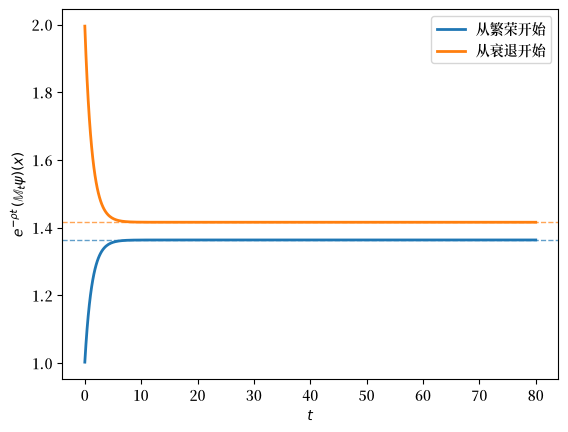

In [7]:
t_grid = np.linspace(0.01, 80, 400)
rescaled = np.array([np.exp(-ρ * t) * expm(t * A) @ ψ for t in t_grid])

fig, ax = plt.subplots()
ax.plot(t_grid, rescaled[:, 0], lw=2, label="从繁荣开始")
ax.plot(t_grid, rescaled[:, 1], lw=2, label="从衰退开始")
ax.axhline(limit[0], color="C0", ls="--", lw=1, alpha=0.7)
ax.axhline(limit[1], color="C1", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("$t$")
ax.set_ylabel(r"$e^{-\rho t}\,(\mathbb{M}_t \psi)(x)$")
ax.legend()
plt.show()

两条实线追踪了从每个状态出发的重新缩放的值，虚线水平线标记了 {eq}`eq:long-run-limit` 所预测的极限。

两条曲线都稳定在其预测的极限上，证实了长期行为仅通过 $\phi$ 依赖于起始状态。

```{note}
渐近指数收敛率由主特征值 $\rho$ 的*实部*与 $A$ 其余特征值中最大实部之间的差距所控制。

对于一个不可约的梅茨勒矩阵，主特征值是实的，其实部严格大于其他特征值，所以这个差距是良定义的。

{ref}`lrr_ex3` 通过一个三状态例子详细说明了如何直接检查这个差距。
```

### 加入跳跃

这个链中的状态转移是不连续的，所以让乘性泛函在转移时刻跳跃是自然的。

这些跳跃是跳跃-扩散参数化中 $\kappa$ 函数的类比。

一个自然的例子出现在一个随机贴现因子上，当经济从衰退进入繁荣时它*向下*跳跃，在反向转移时*向上*跳跃。

下面的矩阵 `κ_jump` 编码了这一点。

我们使用约定 `κ[j, i]` = 转移 $i \to j$ 时 $M$ 的对数跳跃乘子，其中状态索引 0 = 繁荣，状态索引 1 = 衰退。

In [8]:
# 衰退 (1) -> 繁荣 (0): SDF 在好消息时向下跳跃 (exp(-0.20))
# 繁荣 (0) -> 衰退 (1): SDF 在坏消息时向上跳跃 (exp(+0.30))
κ_jump = np.array([[ 0.0, -0.20],
                   [ 0.30,  0.0]])

A_jump = build_generator(U, r, κ_jump)
ρ_jump, φ_jump = principal_eigenpair(A_jump)

print(f"ρ without jumps = {ρ:.6f}")
print(f"ρ with jumps    = {ρ_jump:.6f}")
print("\nφ with jumps:")
print(φ_jump)

ρ without jumps = -0.038484
ρ with jumps    = -0.019067

φ with jumps:
[1.10059123 0.89940877]


为看清长期率 $\rho$ 如何响应跳跃风险，我们固定繁荣到衰退的乘子，并随着衰退到繁荣乘子的变化描绘出 $\rho$。

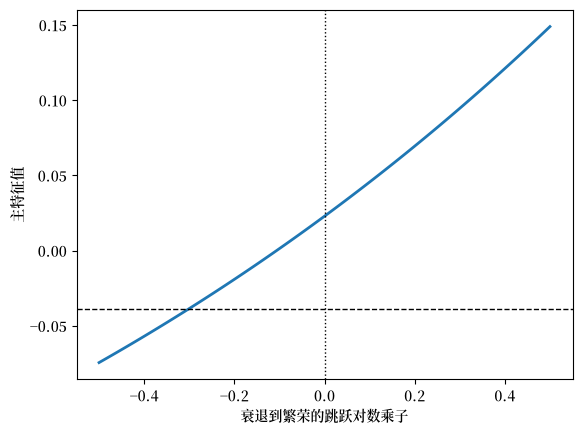

In [9]:
κ_grid = np.linspace(-0.5, 0.5, 100)
ρ_grid = np.empty_like(κ_grid)

for n, k in enumerate(κ_grid):
    κ_temp = np.array([[0.0, k],
                       [0.30, 0.0]])
    A_temp = build_generator(U, r, κ_temp)
    ρ_grid[n], _ = principal_eigenpair(A_temp)

fig, ax = plt.subplots()
ax.plot(κ_grid, ρ_grid, lw=2)
ax.axhline(ρ, color="black", ls="--", lw=1)
ax.axvline(0, color="black", ls=":", lw=1)
ax.set_xlabel("衰退到繁荣的跳跃对数乘子")
ax.set_ylabel("主特征值")
plt.show()

主特征值关于衰退到繁荣的对数乘子单调递增：随着该乘子上升，$M$ 在好消息时向下跳得更少（或向上跳得更多），这机械地推高了 $\rho$。

经济上合理的 SDF 区域在零的左侧，那里乘子为负。

## 仿射扩散例子

我们现在转向一个连续状态模型。

我们将使用一个二因子仿射设定，它捕捉资产回报的两个主要经验特征：

* **随机波动率**，其中冲击的离散度本身是一个状态变量，以及
* **可预测增长**，其中一个小的、持久的状态变量移动期望增长率。

这是长期风险模型（如 {cite:t}`Bansal_Yaron_2004`）中使用的那种状态过程。

我们研究两个独立的状态成分：一个 Feller 平方根过程 $X^f$（随机波动率）和一个 Ornstein-Uhlenbeck 过程 $X^o$（可预测增长）：

$$
\begin{aligned}
dX_t^f
&=
\xi_f(\bar x_f - X_t^f)dt
+ \sqrt{X_t^f}\sigma_f dB_t^f,
\\
dX_t^o
&=
\xi_o(\bar x_o - X_t^o)dt
+ \sigma_o dB_t^o.
\end{aligned}
$$ (eq:affine-state)

参数 $\xi_f, \xi_o>0$ 是均值回归速度，$\bar x_f, \bar x_o$ 是无条件均值，$\sigma_f, \sigma_o$ 是扩散系数。

OU 过程 $X^o$ 是 {doc}`intro:ar1_processes` 中研究的 AR(1) 过程的连续时间类比，同族中的连续时间线性资产定价模型在 {doc}`affine_risk_prices` 中发展。

我们遵循符号约定 $\sigma_o>0$ 和 $\sigma_f<0$：一个正的 $B^f$ 冲击于是*降低*波动率，与经验上的 "杠杆效应" 一致。

现在考虑一个具有仿射参数的乘性泛函 $M=\exp(A)$：

$$
\begin{aligned}
A_t
&=
\bar\beta t
+ \int_0^t \beta_f X_s^f\, ds
+ \int_0^t \beta_o X_s^o\, ds
\\
&\quad
+ \int_0^t \sqrt{X_s^f}\,\gamma_f\, dB_s^f
+ \int_0^t \gamma_o\, dB_s^o .
\end{aligned}
$$ (eq:affine-additive)

所以 $A$ 的漂移关于状态是仿射的（$\bar\beta + \beta_f X^f + \beta_o X^o$），布朗载荷在 $B^o$ 方向上是常数，在 $B^f$ 方向上与 $\sqrt{X^f}$ 成比例。

### 为什么指数-仿射特征函数有效

当状态是仿射的且 $A$ 的漂移是仿射的时，将生成元应用于一个指数-仿射函数 $\phi(x^f,x^o) = \exp(c_f x^f + c_o x^o)$ 会返回另一个指数-仿射函数。

这个封闭性质将特征值方程 $\mathbb A\phi = \rho\phi$ 转化为关于 $(c_f, c_o, \rho)$ 的一个小型代数方程组。

```{prf:definition} 指数-仿射特征函数
:label: lrr-def-exponential-affine-eigenfunction

如果对某个常数 $c_0 \in \mathbb R$ 和向量 $c \in \mathbb R^n$，

$$
    \phi(x) = \exp(c_0 + c^\top x)
    \qquad \text{对所有 } x \in \mathcal D_0 ,
$$

则状态空间 $\mathcal D_0 \subseteq \mathbb R^n$ 上 $\mathbb A$ 的特征函数 $\phi$ 是**指数-仿射的**。
```

将 $\phi(x^f,x^o) = \exp(c_f x^f + c_o x^o)$ 代入生成元公式 {eq}`eq:extended-generator` 并匹配 $x^f$、$x^o$ 和常数项的系数，得到

$$
0
=
\beta_f
+ \frac{\gamma_f^2}{2}
+ c_f(\gamma_f\sigma_f-\xi_f)
+ c_f^2\frac{\sigma_f^2}{2},
$$ (eq:cf-eq)

以及

$$
    c_o = \frac{\beta_o}{\xi_o}.
$$ (eq:co-eq)

$c_f$ 的两个候选值为

$$
c_f
=
\frac{
    \xi_f-\gamma_f\sigma_f
    \pm
    \sqrt{
        (\xi_f-\gamma_f\sigma_f)^2
        - \sigma_f^2(2\beta_f+\gamma_f^2)
    }
}{\sigma_f^2}.
$$ (eq:cf-roots)

特征值随后通过匹配常数项确定：

$$
\rho
=
\bar\beta
+ \frac{\gamma_o^2}{2}
+ c_f \xi_f \bar x_f
+ c_o(\xi_o\bar x_o+\gamma_o\sigma_o)
+ c_o^2 \frac{\sigma_o^2}{2}.
$$ (eq:affine-rho)

方程 {eq}`eq:cf-roots` 给出 $c_f$ 的两个候选值，我们需要知道哪一个是主特征函数。

这就是随机稳定性（{prf:ref}`lrr-def-stochastic-stability`）真正起作用的地方。

在扭曲测度下，$X^f$ 的漂移为

$$
    \xi_f(\bar x_f - x^f)
    + x^f\sigma_f(\gamma_f+c_f\sigma_f),
$$

所以均值回归系数变为

$$
    \xi_f - \sigma_f(\gamma_f+c_f\sigma_f) .
$$

如果这是正的，扭曲平方根过程保持平稳；如果它是负的，扭曲过程是爆炸性的，特征函数不是长期相关的那个。

所以我们**选取使扭曲过程保持均值回归的那个根**，这正是抽象理论中随机稳定性选择主特征函数的方式。

In [10]:
def solve_affine_eigenfunction(params):
    """求解指数-仿射特征值问题。"""
    ξ_f = params["ξ_f"]
    xbar_f = params["xbar_f"]
    σ_f = params["σ_f"]
    ξ_o = params["ξ_o"]
    xbar_o = params["xbar_o"]
    σ_o = params["σ_o"]
    β_bar = params["β_bar"]
    β_f = params["β_f"]
    β_o = params["β_o"]
    γ_f = params["γ_f"]
    γ_o = params["γ_o"]

    co = β_o / ξ_o

    disc = ((ξ_f - γ_f * σ_f) ** 2
            - σ_f ** 2 * (2 * β_f + γ_f ** 2))

    if disc < 0:
        raise ValueError("No real affine eigenfunction for these parameters.")

    root = np.sqrt(disc)
    cf_roots = (
        ((ξ_f - γ_f * σ_f) - root) / σ_f ** 2,
        ((ξ_f - γ_f * σ_f) + root) / σ_f ** 2
    )

    def mean_reversion(cf):
        return ξ_f - σ_f * (γ_f + cf * σ_f)

    for cf in cf_roots:
        mr = mean_reversion(cf)
        if mr > 0:
            break
    else:
        raise ValueError("Neither root gives a stationary twisted process.")

    ρ = (β_bar
         + γ_o ** 2 / 2
         + cf * ξ_f * xbar_f
         + co * (ξ_o * xbar_o + γ_o * σ_o)
         + co ** 2 * σ_o ** 2 / 2)

    return cf, co, ρ, mr

### 一个 Breeden SDF

为使问题具体化，我们现在代入一个特定的随机贴现因子：Breeden CRRA 基于消费的 SDF。

{cite:t}`Breeden1979` 为一个对消费流具有时间可分 CRRA 偏好的投资者推导了连续时间 SDF。

我们用同样的仿射状态 $X^o$ 驱动期望增长、$\sqrt{X^f}$ 驱动波动率来设定对数消费：

$$
    dc_t
    =
    X_t^o\, dt
    + \sqrt{X_t^f}\,\vartheta_f\, dB_t^f
    + \vartheta_o\, dB_t^o .
$$

在时间可分 CRRA 效用（风险厌恶 $a$）和主观贴现率 $b$ 下，随机贴现因子为

$$
    S_t
    =
    \exp\!\big(-bt - a(c_t-c_0)\big),
$$

即 $-b$ 乘以时间减去 $a$ 乘以对数消费增长的指数。

读出可加泛函系数给出

$$
    \bar\beta^s = -b,
    \quad
    \beta_f^s = 0,
    \quad
    \beta_o^s = -a,
    \quad
    \gamma_f^s = -a\vartheta_f,
    \quad
    \gamma_o^s = -a\vartheta_o .
$$ (eq:breeden-sdf-params)

我们将在下面的数值例子中使用这些参数。

### 递归偏好（可选）

CRRA 偏好的一个著名局限是它将风险厌恶与跨期替代弹性混为一谈。

递归偏好 {cite:t}`Kreps_Porteus1978, Epstein_Zin1989` 将两者分开，并在贴现因子表达式中加入一个前瞻性的延续值项。

这就是驱动 {cite:t}`Bansal_Yaron_2004` 中股权溢价结果的机制。

一篇在不同设定下研究递归偏好下长期动态的 QuantEcon 讲座是 {doc}`survival_recursive_preferences`。

本节推导单位弹性递归设定的 SDF 系数。

你可以在第一次阅读时跳过，稍后再回来——数值例子使用上面较简单的 Breeden 参数。

对于单位弹性递归设定，猜测一个如下形式的延续值

$$
    W_t
    =
    \frac{1}{1-a}
    \exp\left[
        (1-a)(w_f X_t^f + w_o X_t^o + c_t + \bar w)
    \right],
    \qquad a>1 .
$$ (eq:kp-continuation-value)

匹配这个延续值的局部均值给出

$$
\begin{aligned}
0
&=
-\xi_f w_f
+ \frac{(1-a)\sigma_f^2}{2}w_f^2
+ (1-a)\vartheta_f\sigma_f w_f
+ \frac{(1-a)\vartheta_f^2}{2}
- b w_f,
\\
0
&=
-\xi_o w_o + 1 - b w_o,
\\
b\bar w
&=
\xi_f \bar x_f w_f
+ \xi_o \bar x_o w_o
+ \frac{(1-a)\sigma_o^2}{2}w_o^2
+ (1-a)\vartheta_o\sigma_o w_o
+ \frac{(1-a)\vartheta_o^2}{2}.
\end{aligned}
$$ (eq:kp-continuation-coefficients)

相关解有 $w_o=1/(\xi_o+b)$，为 $w_f$ 选择二次方程的稳定根，然后从常数方程确定 $\bar w$。

随机贴现因子是乘积 $S_t=\exp(A_t^B)\exp(A_t^W)$，其中类 Breeden 的对数成分为

$$
    A_t^B
    =
    -bt
    - \int_0^t X_s^o ds
    - \int_0^t \sqrt{X_s^f}\vartheta_f dB_s^f
    - \int_0^t \vartheta_o dB_s^o
$$

延续值鞅成分为

$$
\begin{aligned}
    A_t^W
    &=
    (1-a)\int_0^t
        \sqrt{X_s^f}(\vartheta_f+w_f\sigma_f)dB_s^f
    + (1-a)\int_0^t
        (\vartheta_o+w_o\sigma_o)dB_s^o
\\
    &\quad
    - \frac{(1-a)^2}{2}
        \int_0^t X_s^f(\vartheta_f+w_f\sigma_f)^2ds
    - \frac{(1-a)^2}{2}
        (\vartheta_o+w_o\sigma_o)^2t .
\end{aligned}
$$ (eq:kp-sdf-components)

因此递归效用 SDF 具有仿射参数

$$
\begin{aligned}
\bar\beta^s
&=
-b-\frac{(1-a)^2}{2}(\vartheta_o+w_o\sigma_o)^2,
\\
\beta_f^s
&=
-\frac{(1-a)^2}{2}(\vartheta_f+w_f\sigma_f)^2,
\\
\beta_o^s
&= -1,
\\
\gamma_f^s
&=
-a\vartheta_f-(a-1)w_f\sigma_f,
\\
\gamma_o^s
&=
-a\vartheta_o-(a-1)w_o\sigma_o .
\end{aligned}
$$ (eq:kp-sdf-params)

因此局部布朗风险价格为 $B^f$ 暴露的 $\sqrt{x^f}[a\vartheta_f+(a-1)w_f\sigma_f]$ 和 $B^o$ 暴露的 $a\vartheta_o+(a-1)w_o\sigma_o$。

下面的数值例子使用较简单的 Breeden 设定，但一旦将 SDF 参数替换为 {eq}`eq:kp-sdf-params`，同样的算子计算就适用。

### 数值例子

让我们设定参数并求解主特征对。

我们使用标准长期风险邻域中的参数：一个均值回归波动率因子 $X^f$，均值为 $0.04$，一个移动更慢的可预测增长因子 $X^o$，均值为 $0.02$，风险厌恶 $a=4$，以及时间贴现率 $b=0.03$。

In [11]:
params_state = {
    "ξ_f": 0.70,
    "xbar_f": 0.04,
    "σ_f": -0.20,
    "ξ_o": 0.50,
    "xbar_o": 0.02,
    "σ_o": 0.01,
}

a = 4.0
b = 0.03
ϑ_f = 0.06
ϑ_o = 0.02

params_sdf = {
    **params_state,
    "β_bar": -b,
    "β_f": 0.0,
    "β_o": -a,
    "γ_f": -a * ϑ_f,
    "γ_o": -a * ϑ_o,
}

cf_s, co_s, ρ_s, mr_s = solve_affine_eigenfunction(params_sdf)

print("principal eigenfunction φ(xf, xo) = exp(cf xf + co xo)")
print(f"cf = {cf_s:.6f}")
print(f"co = {co_s:.6f}")
print(f"ρ = {ρ_s:.6f}")
print(f"twisted mean-reversion coefficient for Xf = {mr_s:.6f}")
print(f"long-run zero-coupon yield = {-ρ_s:.4f}")

principal eigenfunction φ(xf, xo) = exp(cf xf + co xo)
cf = 0.044232
co = -8.000000
ρ = -0.095962
twisted mean-reversion coefficient for Xf = 0.650231
long-run zero-coupon yield = 0.0960


长期零息收益率 $-\rho_s$ 表示 SDF 期望 $\mathbb{E}[S_t]$ 中的渐近衰减率。

我们还可以检查 $c_f$ 被拒绝的根本会产生一个非平稳的扭曲过程，这是随机稳定性在两个代数上有效的特征函数中选择其一的一个清晰例子。

In [12]:
ξ_f = params_sdf["ξ_f"]
σ_f = params_sdf["σ_f"]
γ_f = params_sdf["γ_f"]
β_f = params_sdf["β_f"]

disc = ((ξ_f - γ_f * σ_f) ** 2
        - σ_f ** 2 * (2 * β_f + γ_f ** 2))
root = np.sqrt(disc)

cf_candidates = np.array([
    ((ξ_f - γ_f * σ_f) - root) / σ_f ** 2,
    ((ξ_f - γ_f * σ_f) + root) / σ_f ** 2
])

for cf in cf_candidates:
    mr = ξ_f - σ_f * (γ_f + cf * σ_f)
    print(f"cf = {cf:8.4f}, twisted mean reversion = {mr:8.4f}")

cf =   0.0442, twisted mean reversion =   0.6502
cf =  32.5558, twisted mean reversion =  -0.6502


### 鞅成分

现在我们有了特征对 $(\rho,\phi)$，我们可以显式写出分解 {eq}`eq:hs-factorization` 的所有三个部分。

{eq}`eq:mhat` 中定义的鞅成分 $\hat M_t = \exp(\hat A_t)$ 的对数为

$$
\begin{aligned}
\hat A_t
&=
\int_0^t \sqrt{X_s^f}(\gamma_f+c_f\sigma_f)\, dB_s^f
+ \int_0^t (\gamma_o+c_o\sigma_o)\, dB_s^o
\\
&\quad
- \frac{1}{2}\int_0^t X_s^f(\gamma_f+c_f\sigma_f)^2\, ds
- \frac{1}{2}\int_0^t (\gamma_o+c_o\sigma_o)^2\, ds .
\end{aligned}
$$

第一行是布朗积分（"指数鞅" 部分）；第二行是使它成为鞅所需的伊藤修正。

在由 $\hat M$ 诱导的扭曲测度下，状态变量的漂移移动为

$$
\begin{aligned}
dX_t^f:
\quad&
\xi_f(\bar x_f-X_t^f)
+ X_t^f \sigma_f(\gamma_f+c_f\sigma_f),
\\
dX_t^o:
\quad&
\xi_o(\bar x_o-X_t^o)
+ \sigma_o(\gamma_o+c_o\sigma_o).
\end{aligned}
$$

漂移扭曲恰好是由 $\hat M$ 的布朗载荷诱导的 Girsanov 移动。

现在让我们模拟状态并数值检查分解。

第一个检查是*代数恒等式*：一旦我们通过 {eq}`eq:mhat` 定义 $\hat M$，方程 $M_t = \exp(\rho t)\hat M_t \phi(X_0)/\phi(X_t)$ 对任何 $(\rho,\phi)$ 的选择都自动成立，下面的误差只是浮点舍入。

第二个更实质性的检查是我们求解出的特征对 $(\rho,\phi)$ 是否真的使 $\hat M$ 成为一个鞅，我们通过在许多模拟路径上计算 $\mathbb{E}[\hat M_t]$ 来近似。

In [13]:
def brownian_increments(n, dt, seed=1234):
    """用于模拟的独立布朗增量。"""
    rng = np.random.default_rng(seed)
    draws = rng.normal(scale=np.sqrt(dt), size=(n, 2))
    return draws[:, 0], draws[:, 1]


def simulate_states(params, T=40.0, dt=0.01, seed=1234):
    """仿射状态过程的欧拉模拟。"""
    n = int(T / dt)
    t = np.linspace(0, T, n + 1)
    Xf = np.empty(n + 1)
    Xo = np.empty(n + 1)
    dBf, dBo = brownian_increments(n, dt, seed)

    Xf[0] = params["xbar_f"]
    Xo[0] = params["xbar_o"]

    for k, (dBf_k, dBo_k) in enumerate(zip(dBf, dBo)):
        xf = max(Xf[k], 1e-10)
        xo = Xo[k]

        Xf[k + 1] = (xf
                     + params["ξ_f"] * (params["xbar_f"] - xf) * dt
                     + np.sqrt(xf) * params["σ_f"] * dBf_k)
        Xf[k + 1] = max(Xf[k + 1], 1e-10)

        Xo[k + 1] = (xo
                     + params["ξ_o"] * (params["xbar_o"] - xo) * dt
                     + params["σ_o"] * dBo_k)

    return t, Xf, Xo, dBf, dBo


def additive_log_M(params, t, Xf, Xo, dBf, dBo):
    """沿模拟路径的可加对数泛函。"""
    dt = t[1] - t[0]
    A = np.zeros_like(t)

    for k, (dBf_k, dBo_k) in enumerate(zip(dBf, dBo)):
        xf = max(Xf[k], 1e-10)
        xo = Xo[k]

        drift = (params["β_bar"]
                 + params["β_f"] * xf
                 + params["β_o"] * xo)

        shock = (np.sqrt(xf) * params["γ_f"] * dBf_k
                 + params["γ_o"] * dBo_k)

        A[k + 1] = A[k] + drift * dt + shock

    return A


t, Xf, Xo, dBf, dBo = simulate_states(params_sdf)
A_log = additive_log_M(params_sdf, t, Xf, Xo, dBf, dBo)

φ_0 = np.exp(cf_s * Xf[0] + co_s * Xo[0])
φ_t = np.exp(cf_s * Xf + co_s * Xo)

M = np.exp(A_log)
M_hat = np.exp(-ρ_s * t) * M * φ_t / φ_0
transient = φ_0 / φ_t

identity_error = np.max(np.abs(M - np.exp(ρ_s * t) * M_hat * transient))
print(f"algebraic identity error = {identity_error:.2e}")

algebraic identity error = 2.22e-16


上面的误差达到机器精度，符合预期。

接下来我们在路径的蒙特卡洛样本上估计 $\mathbb{E}[\hat M_t \mid X_0 = \bar x]$。

如果 $\hat M$ 是一个鞅，那么总体均值在每个 $t$ 处恰好为 $1$，样本均值应落在 $1$ 的几个标准误之内。

In [14]:
def simulate_M_hat(params, ρ, cf, co, n_paths=2000, T=20.0, dt=0.01, seed=2024):
    """沿一组轨迹的 hat M_t 的蒙特卡洛路径。"""
    rng = np.random.default_rng(seed)
    n = int(T / dt)
    t = np.linspace(0, T, n + 1)
    M_hat_paths = np.empty((n_paths, n + 1))

    for k in range(n_paths):
        seed_k = rng.integers(1, 10**9)
        t_k, Xf_k, Xo_k, dBf_k, dBo_k = simulate_states(
            params, T=T, dt=dt, seed=int(seed_k)
        )
        A_k = additive_log_M(params, t_k, Xf_k, Xo_k, dBf_k, dBo_k)
        φ_t_k = np.exp(cf * Xf_k + co * Xo_k)
        φ_0_k = np.exp(cf * Xf_k[0] + co * Xo_k[0])
        M_hat_paths[k] = np.exp(-ρ * t_k) * np.exp(A_k) * φ_t_k / φ_0_k

    return t, M_hat_paths


t_mc, M_hat_paths = simulate_M_hat(params_sdf, ρ_s, cf_s, co_s)
M_hat_mean = M_hat_paths.mean(axis=0)
M_hat_se = M_hat_paths.std(axis=0, ddof=1) / np.sqrt(M_hat_paths.shape[0])

print("   t      mean       se      (mean - 1) / se")
for t_check in [1.0, 5.0, 10.0, 20.0]:
    idx = np.argmin(np.abs(t_mc - t_check))
    mean = M_hat_mean[idx]
    se = M_hat_se[idx]
    z = (mean - 1.0) / se
    print(f"{t_mc[idx]:5.2f}   {mean:7.4f}  {se:7.4f}   {z:+6.2f}")

   t      mean       se      (mean - 1) / se
 1.00    0.9974   0.0038    -0.68
 5.00    0.9928   0.0087    -0.83
10.00    1.0005   0.0129    +0.04
20.00    1.0020   0.0201    +0.10


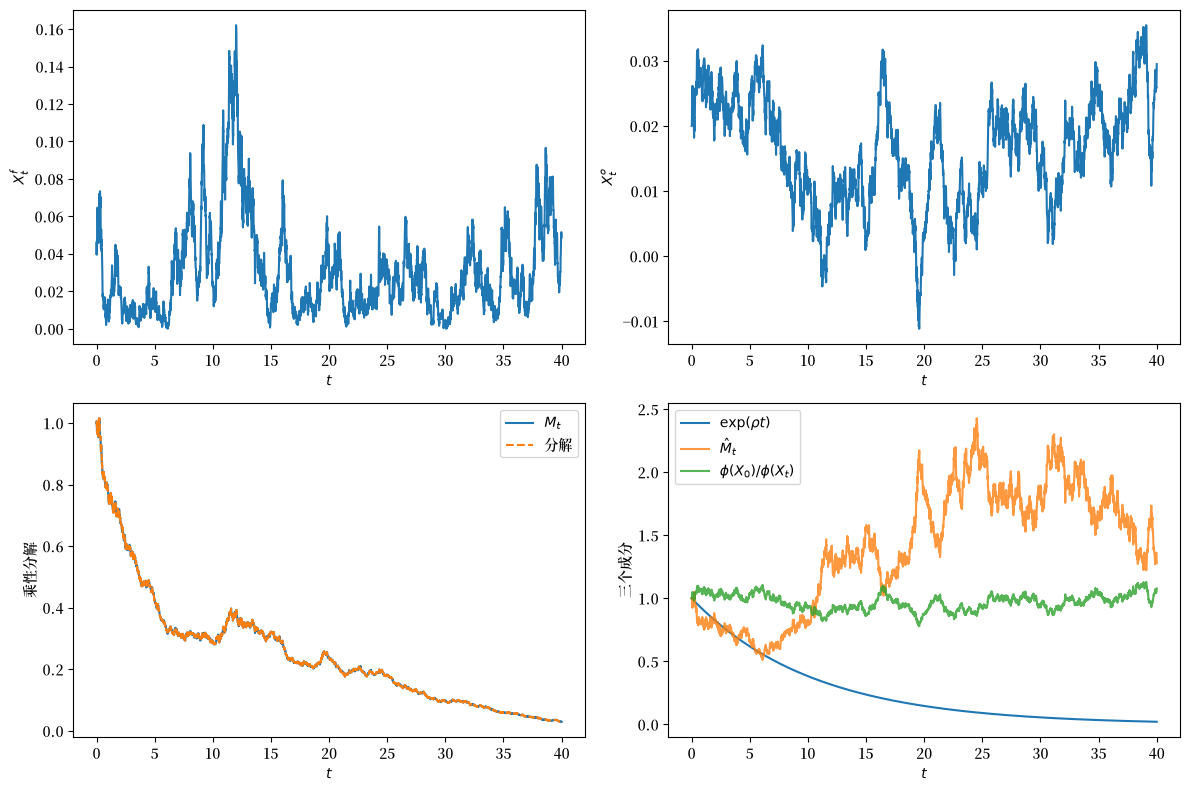

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(t, Xf)
axes[0, 0].set_ylabel("$X_t^f$")
axes[0, 0].set_xlabel("$t$")

axes[0, 1].plot(t, Xo)
axes[0, 1].set_ylabel("$X_t^o$")
axes[0, 1].set_xlabel("$t$")

axes[1, 0].plot(t, M, label="$M_t$")
axes[1, 0].plot(t, np.exp(ρ_s * t) * M_hat * transient,
                "--", label="分解")
axes[1, 0].set_ylabel("乘性分解")
axes[1, 0].set_xlabel("$t$")
axes[1, 0].legend()

axes[1, 1].plot(t, np.exp(ρ_s * t), label="$\\exp(\\rho t)$")
axes[1, 1].plot(t, M_hat, label="$\\hat M_t$", alpha=0.8)
axes[1, 1].plot(t, transient, label="$\\phi(X_0)/\\phi(X_t)$", alpha=0.8)
axes[1, 1].set_ylabel("三个成分")
axes[1, 1].set_xlabel("$t$")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

该图展示了这三个成分如何随时间演化。

## 长期风险价格

我们现在可以使用该分解来计算标准连续时间资产定价中出现的瞬时风险价格的长期类比。

我们可以问：

> 如果一个投资者今天承担对某个冲击的小暴露，当回报按长视界率而非瞬时率衡量时，他们需要多少额外的期望回报？

这两个答案，局部的和长期的，不一定一致。

一个移动持久性状态变量的冲击对现金流有一个小的*即时*影响，但对未来期望增长和贴现有一个大的*累积*影响，这就是这两个答案分开的原因。

所以长期风险价格是局部价格*加上一个持久性修正*。

修正的大小取决于均值回归的速度。

### 定义价格

```{prf:definition} 局部布朗风险价格
:label: lrr-def-local-brownian-risk-price

**局部布朗风险价格**是依赖状态的向量 $-\gamma^s(x)$。

一个小的布朗暴露 $\gamma^v_i$ 每单位时间赚取所需的期望回报 $-\gamma^v_i \gamma^s_i$，所以一单位暴露 $\gamma^v_i$ 的定价为 $-\gamma^s_i$。
```

对于局部价格，我们只需读出 SDF 系数。

```{prf:definition} 长期风险价格
:label: lrr-def-long-run-risk-price

**长期风险价格**是现金流的长期所需回报关于其风险暴露的小变化的边际变化。

当我们处理增长现金流时，长期所需回报为 $R_\infty = -\rho + \delta$，其中 $\rho$ 是 $GS$ 半群的主特征值，$\delta$ 是趋势增长率，保持固定。
```

计算长期价格需要求解主特征值问题，它捕捉了一个冲击如何通过持久性状态成分传播。

### 两个前沿

我们将看到*两种*相关的改变风险暴露的方式，每种都导致一个略微不同的长期风险价格：

1. **估值泛函前沿：**
   - 保持 SDF $S$ 固定并改变资产的布朗暴露 $(\gamma^v_f, \gamma^v_o)$。

   - 使用局部定价约束确定漂移 $\beta^v$，然后计算 $V$-半群的 $\rho^v$。

2. **现金流前沿：**
   - 保持 SDF $S$ 固定并改变现金流的增长暴露 $(\gamma^g_f, \gamma^g_o)$。
   - 设 $M = GS$ 并计算现金流估值半群的主特征值 $\rho$。

在简单的对数正态例子中，这两个前沿重合。

但在有随机波动率、非线性动态或跳跃风险时它们可能不同。

我们将在下面的仿射模型中详细讨论这两种类型的例子。

### 随机贴现因子分解

在进入风险价格之前，一个自然的基准是情形 $M=S$：将分解 {eq}`eq:hs-factorization` 直接应用于 SDF 本身。

分解变为

$$
    S_t
    =
    \exp(\rho t)\hat M_t
    \frac{\phi(X_0)}{\phi(X_t)} .
$$

这是 {cite:t}`AlvarezJermann2005` 的**永久-瞬态分解**，现在与一个具体的特征函数构造相联系。

因子 $\exp(\rho t)$ 是 SDF 中的确定性趋势，鞅 $\hat M$ 是其随机*永久*成分；依赖状态的比值是*瞬态*的且会消失。

```{seealso}
定价算子的同一谱分解是 {doc}`ross_recovery` 中的核心工具，它用来从观察到的价格中 "恢复" 主观信念，也是 {doc}`misspecified_recovery` 中的核心工具，后者考察当永久鞅成分被错误地假设不存在时会出什么问题。
```

对于一个长期零息债券，

$$
    \exp(-\rho t)\, \mathbb{E}[S_t \mid X_0=x]
    \to
    \phi(x)
    \int \frac{1}{\phi}\, d\hat\varsigma ,
$$

所以长期限贴现债券价格主要通过特征函数 $\phi$ 依赖于当前状态。

### 仿射模型中的比较

对于仿射设定，我们可以为 $B^o$ 冲击的局部和长期价格写出闭式表达式。

局部价格就是

$$
    \text{$B^o$ 的局部价格} = -\gamma_o^s.
$$

长期价格（我们将在下面使用估值泛函前沿推导它）为

$$
    \text{$B^o$ 的长期价格}
    =
    -\gamma_o^s
    - \frac{\beta_o^s}{\xi_o}\sigma_o .
$$ (eq:long-run-price-o)

额外项 $-(\beta_o^s/\xi_o)\sigma_o$ 是**持久性修正**。

它的出现是因为：

* 一个 $B^o$ 冲击移动持久性增长预测因子 $X^o$，以及
* $X^o$ 以速率 $\xi_o$ 均值回归，所以该冲击对未来 SDF 增长的累积影响像 $1/\xi_o$ 一样缩放。

随着 $\xi_o$ 收缩，持久性增长，长期价格与局部价格分离，这是长期风险模型的核心经济内容。

$B^f$ 暴露的局部价格是依赖状态的（它随 $\sqrt{X^f_t}$ 缩放），$B^f$ 暴露的长期价格是非线性的，因为 $c_f$ 是一个二次方程的根。

In [16]:
γ_s_o = params_sdf["γ_o"]
β_s_o = params_sdf["β_o"]
ξ_o = params_sdf["ξ_o"]
σ_o = params_sdf["σ_o"]

local_price_o = -γ_s_o
long_run_price_o = -γ_s_o - (β_s_o / ξ_o) * σ_o

print(f"local price of B^o exposure    = {local_price_o:.4f}")
print(f"long-run price of B^o exposure = {long_run_price_o:.4f}")

local price of B^o exposure    = 0.0800
long-run price of B^o exposure = 0.1600


下一个单元格说明持久性如何改变局部与长期价格之间的楔子。

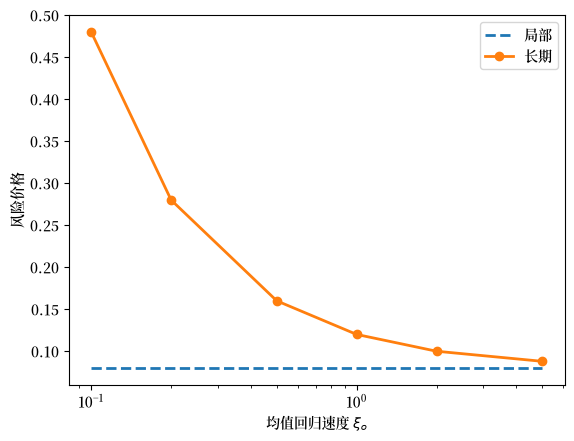

In [17]:
ξ_o_grid = np.array([0.10, 0.20, 0.50, 1.00, 2.00, 5.00])
local_grid = np.full_like(ξ_o_grid, local_price_o)
long_grid = -γ_s_o - (β_s_o / ξ_o_grid) * σ_o

fig, ax = plt.subplots()
ax.plot(ξ_o_grid, local_grid, "--", lw=2, label="局部")
ax.plot(ξ_o_grid, long_grid, "o-", lw=2, label="长期")
ax.set_xscale("log")
ax.set_xlabel("均值回归速度 $\\xi_o$")
ax.set_ylabel("风险价格")
ax.legend()
plt.show()

如我们所见，$B^o$ 暴露的长期价格对均值回归速度 $\xi_o$ 敏感，但局部价格是常数。

### 改变估值泛函

现在我们通过改变资产的暴露来推导长期风险价格公式，即上面介绍的**估值泛函前沿**。

我们保持 SDF $S$ 固定并为资产回报选取布朗暴露 $(\gamma_f^v,\gamma_o^v)$，将估值泛函参数化为

$$
\begin{aligned}
A_t^v
&=
\bar\beta^v t
+ \int_0^t \beta_f^v X_s^f ds
+ \int_0^t \beta_o^v X_s^o ds
\\
&\quad
+ \int_0^t \sqrt{X_s^f}\gamma_f^v dB_s^f
+ \int_0^t \gamma_o^v dB_s^o .
\end{aligned}
$$

$VS$ 上的鞅约束根据所选布朗暴露 $(\gamma_f^v,\gamma_o^v)$ 确定漂移系数：

$$
\begin{aligned}
\bar\beta^v
&=
-\bar\beta^s
- \frac{1}{2}(\gamma_o^s+\gamma_o^v)^2,
\\
\beta_f^v
&=
-\beta_f^s
- \frac{1}{2}(\gamma_f^s+\gamma_f^v)^2,
\\
\beta_o^v
&=
-\beta_o^s .
\end{aligned}
$$ (eq:valuation-local-restriction-affine)

将仿射特征值公式应用于 $M=V$ 给出

$$
\begin{aligned}
\rho^v
&=
\bar\beta^v
+ \frac{(\gamma_o^v)^2}{2}
+ c_f^v \xi_f \bar x_f
+ c_o^v(\xi_o\bar x_o+\gamma_o^v\sigma_o)
+ (c_o^v)^2\frac{\sigma_o^2}{2}
\\
&=
-\bar\beta^s
- \frac{(\gamma_o^s)^2}{2}
- \gamma_o^s\gamma_o^v
+ c_f^v \xi_f \bar x_f
+ c_o^v(\xi_o\bar x_o+\gamma_o^v\sigma_o)
+ (c_o^v)^2\frac{\sigma_o^2}{2},
\end{aligned}
$$ (eq:valuation-rho-affine)

其中 $c_o^v=\beta_o^v/\xi_o=-\beta_o^s/\xi_o$，$c_f^v$ 求解与 {eq}`eq:cf-eq` 中相同的二次方程，只是将 $(\beta_f,\gamma_f)$ 替换为 $(\beta_f^v,\gamma_f^v)$。

保持 $\gamma_f^v$ 固定，将 {eq}`eq:valuation-rho-affine` 关于 $\gamma_o^v$ 求导给出 $B^o$ 暴露的长期估值泛函价格：

$$
    \frac{\partial \rho^v}{\partial \gamma_o^v}
    =
    -\gamma_o^s
    + c_o^v\sigma_o
    =
    -\gamma_o^s
    - \frac{\beta_o^s}{\xi_o}\sigma_o .
$$ (eq:valuation-long-run-price-o)

这与我们上面预览的公式 {eq}`eq:long-run-price-o` 匹配，即局部价格加上持久性修正 $-(\beta_o^s/\xi_o)\sigma_o$。

让我们通过对特征值计算作有限差分来数值验证该公式。

In [18]:
def valuation_params_from_exposure(γ_v_o, γ_v_f=0.0):
    """估值泛函 V 的仿射参数。"""
    p = dict(params_sdf)
    p.update({
        "β_bar": (-params_sdf["β_bar"]
                  - 0.5 * (params_sdf["γ_o"] + γ_v_o) ** 2),
        "β_f": (-params_sdf["β_f"]
                - 0.5 * (params_sdf["γ_f"] + γ_v_f) ** 2),
        "β_o": -params_sdf["β_o"],
        "γ_f": γ_v_f,
        "γ_o": γ_v_o,
    })
    return p


def valuation_eigenvalue_for_exposure(γ_v_o, γ_v_f=0.0):
    """估值泛函前沿的主特征值。"""
    p = valuation_params_from_exposure(γ_v_o, γ_v_f)
    _, _, ρ, _ = solve_affine_eigenfunction(p)
    return ρ

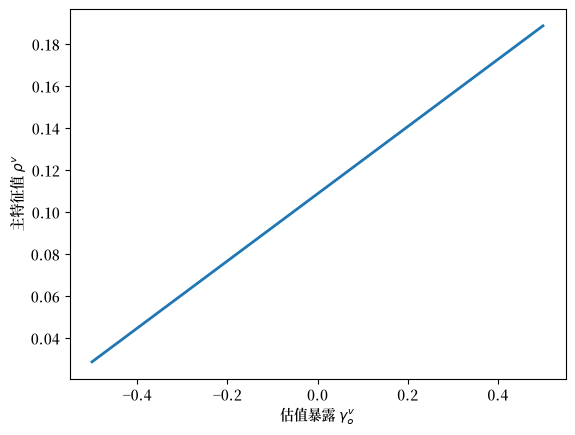

In [19]:
γ_v_o_grid = np.linspace(-0.5, 0.5, 101)
ρ_v_grid = np.array([
    valuation_eigenvalue_for_exposure(g) for g in γ_v_o_grid
])

fig, ax = plt.subplots()
ax.plot(γ_v_o_grid, ρ_v_grid, lw=2)
ax.set_xlabel("估值暴露 $\\gamma_o^v$")
ax.set_ylabel("主特征值 $\\rho^v$")
plt.show()

In [20]:
valuation_slope = (
    valuation_eigenvalue_for_exposure(0.001)
    - valuation_eigenvalue_for_exposure(-0.001)
) / 0.002

print(f"finite-difference slope = {valuation_slope:.6f}")
print(f"formula                 = {long_run_price_o:.6f}")

finite-difference slope = 0.160000
formula                 = 0.160000


### 改变现金流风险

第二个长期前沿改变现金流对风险的暴露而非回报。

我们选取一个增长泛函 $G_t = \exp(A_t^g)$，采用仿射参数化

$$
\begin{aligned}
A_t^g
&=
\delta t
+ \int_0^t \sqrt{X_s^f}\gamma_f^g dB_s^f
+ \int_0^t \gamma_o^g dB_s^o
\\
&\quad
- \frac{1}{2}
  \int_0^t
    \left[
        X_s^f(\gamma_f^g)^2 + (\gamma_o^g)^2
    \right] ds .
\end{aligned}
$$ (eq:growth-functional)

最后一行是使 $\exp(A_t^g-\delta t) = \hat G_t$ 成为一个*局部*鞅的伊藤补偿子，其中 $\delta$ 是常数趋势增长率。

增长-扭曲过程的随机稳定性需要三个条件。

**Feller 型不可达**不等式

$$
    2(\xi_f+\sigma_f\gamma_f^g)\bar x_f \geq \sigma_f^2
$$

使扭曲的 $X^f$ 不触及零。

扭曲的 $X^f$ 的*均值回归*由我们对 SDF 在 {eq}`eq:cf-roots` 中使用的同样的选根论证挑选。

$\hat G$ 本身必须是一个鞅，即增长扭曲的假设 6.1 的类比。

Feller 不等式是必要的但本身不充分。

```{note}
这个 Feller 限制是我们之前标示的一个一般观点的具体实例：改变增长风险可能违反稳定性并使长期近似失效，所以 $(\gamma_f^g, \gamma_o^g)$ 的选择不是自由的。
```

为给现金流 $D_t=D_0G_t\psi(X_t)$ 定价，使用由 $M=GS$ 生成的半群。

组合的仿射参数为

$$
\begin{aligned}
\bar\beta &= \bar\beta^s+\delta-\frac{(\gamma_o^g)^2}{2},\\
\beta_f &= \beta_f^s-\frac{(\gamma_f^g)^2}{2},\\
\beta_o &= \beta_o^s,\\
\gamma_f &= \gamma_f^s+\gamma_f^g,\\
\gamma_o &= \gamma_o^s+\gamma_o^g.
\end{aligned}
$$

设 $\rho$ 为这个 $GS$ 半群的主特征值。

那么 $-\rho$ 是价值的长期衰减率，以及

$$
    R_\infty = -\rho + \delta
$$

是扣除现金流增长率后的渐近所需回报。

In [21]:
def required_return_for_growth_exposure(γ_g_o, γ_g_f=0.0, δ=0.02):
    """现金流增长暴露的长期所需回报。"""
    p = dict(params_sdf)
    p.update({
        "β_bar": params_sdf["β_bar"] + δ - 0.5 * γ_g_o ** 2,
        "β_f": params_sdf["β_f"] - 0.5 * γ_g_f ** 2,
        "β_o": params_sdf["β_o"],
        "γ_f": params_sdf["γ_f"] + γ_g_f,
        "γ_o": params_sdf["γ_o"] + γ_g_o,
    })

    _, _, ρ, _ = solve_affine_eigenfunction(p)
    return -ρ + δ

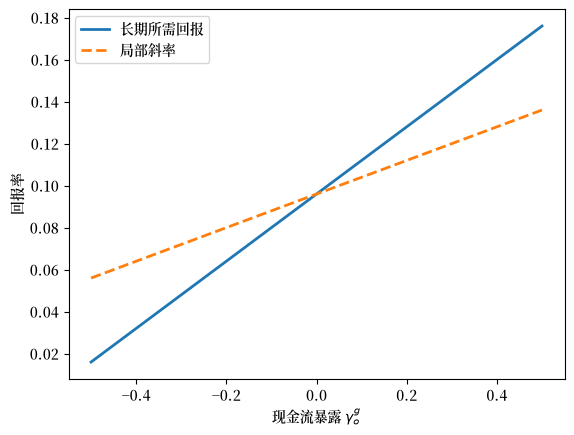

In [22]:
γ_g_o_grid = np.linspace(-0.5, 0.5, 101)
required_returns = np.array([
    required_return_for_growth_exposure(g) for g in γ_g_o_grid
])

local_line = (required_return_for_growth_exposure(0.0)
              + local_price_o * γ_g_o_grid)

fig, ax = plt.subplots()
ax.plot(γ_g_o_grid, required_returns, lw=2,
        label="长期所需回报")
ax.plot(γ_g_o_grid, local_line, "--", lw=2,
        label="局部斜率")
ax.set_xlabel("现金流暴露 $\\gamma_o^g$")
ax.set_ylabel("回报率")
ax.legend()
plt.show()

长期线的斜率是 {eq}`eq:long-run-price-o` 中的风险价格，虚线在 $\gamma_o^g = 0$ 处共享相同的值，但斜率等于局部布朗风险价格 $-\gamma_o^s$。

两条斜率之间的差距是*持久性修正*；虚线是一个斜率比较器，而不是实际的 Breeden 局部期望回报前沿（后者在 $X^f$ 和 $X^o$ 中依赖状态）。

In [23]:
finite_difference = (
    required_return_for_growth_exposure(0.001)
    - required_return_for_growth_exposure(-0.001)
) / 0.002

print(f"finite-difference slope = {finite_difference:.6f}")
print(f"formula                 = {long_run_price_o:.6f}")

finite-difference slope = 0.160000
formula                 = 0.160000


## 幕后的假设

上面的例子使特征函数计算看起来很常规。

对于有限状态链和仿射模型，它确实如此；佩龙-弗罗贝尼乌斯理论和闭式代数处理了每个要求。

但在一般状态空间中，三件事可能出错，每件都对应我们一直所携带的假设之一。

本节其余部分逐一考察每个。

### 问题 1：$\hat M$ 可能无法成为一个鞅

一个正特征函数 $\phi$ 从 {eq}`eq:mhat` 给我们一个候选鞅 $\hat M$，但 $\hat M$ 只是一个非负局部鞅，因而是一个上鞅。

一个上鞅不足以定义一个概率测度：我们需要 $\mathbb{E}[\hat M_t] = 1$，即一个真正的鞅，这是 {cite:t}`HansenScheinkman2009` 中假设 6.1 的内容。

验证这一点的标准方式是一个双侧 **Girsanov 构造**：写出由 $\hat M$ 诱导的漂移和跳跃扭曲，检查扭曲的马尔可夫过程表现良好，并验证反向密度（$\hat M$ 的逆）是局部可积的。

### 问题 2：扭曲过程可能无法稳定

即使 $\hat M$ 是一个鞅，长期极限 {eq}`eq:long-run-limit` 也要求扭曲过程实际上稳定到一个稳态。

这就是随机稳定性（我们的平稳分布、骨架的不可约性和哈里斯常返三者组合）真正起作用的地方。

仿射例子具体说明了这一点，因为我们*拒绝*了两个代数上有效的特征函数中的一个，因为它意味着一个爆炸性的扭曲平方根过程。

### 问题 3：主特征函数可能不存在

在一般状态空间中，即使是严格正特征函数的*存在性*也不是自动的。

一个标准的充分条件从一个 **Lyapunov 型漂移界** 开始：存在一个状态空间上的函数 $V \geq 1$ 和一个常数 $a_0$，使得

$$
    \frac{\mathbb A V}{V} \leq a_0 .
$$

大致上：$V$ 在半群下增长得不太快。

有了这个，对任何 $\alpha > a_0$ 定义**预解算子**

$$
    F_\alpha \psi(x)
    =
    \int_0^\infty
    \exp(-\alpha t)\,
    \mathbb{E}\!\left[
        M_t\, \frac{V(X_t)}{V(x)}\, \psi(X_t)
        \,\Big|\, X_0=x
    \right] dt .
$$ (eq:existence-resolvent)

$F_\alpha$ 是由*重新缩放的*乘性泛函 $M_t V(X_t)/V(X_0)$ 生成的半群的拉普拉斯变换。

存在性证明随后分三步进行：

1. **预解算子的不可约性。** 存在一个参考测度 $\nu$ 使得每当 $\nu(\Lambda) > 0$ 时对每个 $x$ 有 $F_\alpha\mathbf 1_\Lambda(x) > 0$，所以预解算子不 "错过" 状态空间的任何区域。

2. **Nummelin 极小化。** 不可约性产生一个状态空间上的*有界非负函数* $s$，满足 $\int s\, d\nu > 0$，使得对每个非负 $\psi$，

   $$
       F_\alpha \psi(x)\, \geq\, s(x) \int \psi\, d\nu .
   $$

   函数 $s$（通常称为*极小化函数*）度量预解算子在多大程度上支配一个固定参考测度 $\nu$。

3. **特征函数提取。** 极小化结合额外的有界性或强化的漂移假设，识别出 $F_\alpha$ 的一个临界谱值和一个相关联的正特征函数。

   - 反演预解变换产生原半群的一个正特征函数。

这些步骤都是非平凡的，超出了本讲座的范围。

细节在 {cite:t}`HansenScheinkman2009` 的第 9 节。

我们可以将条件链总结为：

| 想要 | 需要 |
|:---|:---|
| 一个分解 {eq}`eq:hs-factorization` | 一个正特征函数 $\phi$ |
| $\hat M$ 定义一个概率测度 | $\hat M$ 是一个鞅（假设 6.1） |
| 长期极限 {eq}`eq:long-run-limit` | 扭曲过程的随机稳定性 |
| 一个唯一的主特征函数 | 稳定性在正特征函数中选择 |

在有限状态情形中，所有四个都从一次佩龙-弗罗贝尼乌斯计算得出；在仿射模型中，它们约化为挑选一个二次方程的正确根。一般而言，每个都必须单独检查。

{cite:t}`HansenScheinkman2009` 中的完整理论还提供了更强的 $L^p$ 近似结果和随机稳定性的 Lyapunov 判据，我们在这里不复现。

## 小结

Hansen-Scheinkman 方法通过研究估值半群的正特征函数来研究长期风险。

主要步骤是：

1. 用一个正乘性泛函 $M$ 对贴现、增长或累积回报建模。

2. 建立半群 $\mathbb M_t\psi(x)=\mathbb{E}[M_t\psi(X_t)\mid X_0=x]$。

3. 当 $M = VS$ 是一个估值泛函和一个 SDF 的乘积时，施加 $VS$ 是一个鞅的局部定价约束；对于现金流估值半群 $\mathbb Q_t = GS$，定价约束仅施加于 $S$，而 $G$ 只作为一个增长扭曲进入。

4. 求解主特征值问题 $\mathbb A\phi=\rho\phi$。

5. 使用分解 $M_t=\exp(\rho t)\hat M_t\phi(X_0)/\phi(X_t)$。

6. 在由 $\hat M$ 诱导的扭曲概率测度下，使用稳定性获得 {eq}`eq:long-run-limit` 形式的长期近似。

在有限状态问题中，这是佩龙-弗罗贝尼乌斯理论。

在仿射扩散问题中，指数-仿射特征函数常产生闭式公式。

当冲击移动持久性状态变量时，出现的长期风险价格可能与局部风险价格显著不同。

这个持久性效应是长期风险资产定价模型和 {cite:t}`hansen2008consumption` 的经验工作中所强调的经济渠道。

## 练习

```{exercise}
:label: lrr_ex1

考虑一个具有强度矩阵

$$
U =
\begin{bmatrix}
    -\lambda & \lambda \\
    \mu & -\mu
\end{bmatrix}.
$$

的两状态马尔可夫链。

设乘性泛函在状态 1 中有衰减率 $r_1>0$，在状态 2 中有衰减率 $r_2=0$，且无跳跃。

1. 写出生成元矩阵 $A$。

2. 用 $\lambda$、$\mu$ 和 $r_1$ 表示主特征值 $\rho$。

3. 用 $\lambda=0.4$、$\mu=0.6$ 和 $r_1=0.05$ 数值验证。

4. 证明 $-r_1 < \rho < 0$。
```

```{solution-start} lrr_ex1
:class: dropdown
```

这是一个解答：

*1.* 生成元为

$$
A =
\begin{bmatrix}
    -\lambda-r_1 & \lambda \\
    \mu & -\mu
\end{bmatrix}.
$$

*2.* 特征方程为

$$
    \rho^2 + (\lambda+\mu+r_1)\rho + \mu r_1 = 0.
$$

因此主特征值是较大的根

$$
\rho
=
\frac{
    -(\lambda+\mu+r_1)
    + \sqrt{(\lambda+\mu+r_1)^2 - 4\mu r_1}
}{2}.
$$

*3.* 数值验证：

In [24]:
λ, μ, r1 = 0.4, 0.6, 0.05

disc = (λ + μ + r1) ** 2 - 4 * μ * r1
ρ_formula = (-(λ + μ + r1) + np.sqrt(disc)) / 2

U_ex = np.array([[-λ, λ],
                 [μ, -μ]])
r_ex = np.array([r1, 0.0])
κ_ex = np.zeros((2, 2))

A_ex = build_generator(U_ex, r_ex, κ_ex)
ρ_numeric, φ_numeric = principal_eigenpair(A_ex)

print(f"formula  ρ = {ρ_formula:.8f}")
print(f"numeric  ρ = {ρ_numeric:.8f}")
print(f"difference   = {abs(ρ_formula-ρ_numeric):.2e}")

formula  ρ = -0.02939431
numeric  ρ = -0.02939431
difference   = 0.00e+00


*4.* 设

$$
q(x)=x^2+(\lambda+\mu+r_1)x+\mu r_1.
$$

那么 $q(0)=\mu r_1>0$ 且

$$
q(-r_1)
=
-\lambda r_1
<0.
$$

由于抛物线开口向上，一个根位于 $(-r_1,0)$ 中。

主特征值是较大的根，所以 $-r_1<\rho<0$。

```{solution-end}
```

```{exercise}
:label: lrr_ex2

在仿射模型中，为

$$
    \xi_o \in \{0.1, 0.2, 0.5, 1, 2, 5\}.
$$

计算 $B^o$ 暴露的局部和长期价格。

使用公式

$$
    \text{局部价格} = -\gamma_o^s
$$

和

$$
    \text{长期价格}
    =
    -\gamma_o^s
    - \frac{\beta_o^s}{\xi_o}\sigma_o .
$$

解释为什么当 $\xi_o \to \infty$ 时两个价格收敛。
```

```{solution-start} lrr_ex2
:class: dropdown
```

这是一个解答：

ξ_o = 0.1: local = 0.0800, long-run = 0.4800
ξ_o = 0.2: local = 0.0800, long-run = 0.2800
ξ_o = 0.5: local = 0.0800, long-run = 0.1600
ξ_o = 1.0: local = 0.0800, long-run = 0.1200
ξ_o = 2.0: local = 0.0800, long-run = 0.1000
ξ_o = 5.0: local = 0.0800, long-run = 0.0880


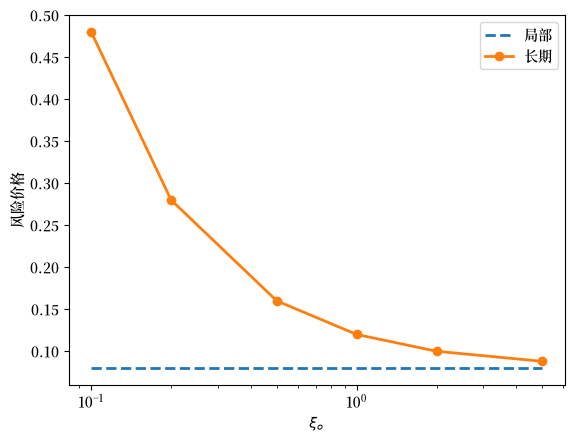

In [25]:
ξ_vals = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0])
local_vals = np.full_like(ξ_vals, -params_sdf["γ_o"])
long_vals = (-params_sdf["γ_o"]
             - (params_sdf["β_o"] / ξ_vals) * params_sdf["σ_o"])

for ξ, lp, lrp in zip(ξ_vals, local_vals, long_vals):
    print(f"ξ_o = {ξ:3.1f}: local = {lp:.4f}, long-run = {lrp:.4f}")

fig, ax = plt.subplots()
ax.plot(ξ_vals, local_vals, "--", lw=2, label="局部")
ax.plot(ξ_vals, long_vals, "o-", lw=2, label="长期")
ax.set_xscale("log")
ax.set_xlabel("$\\xi_o$")
ax.set_ylabel("风险价格")
ax.legend()
plt.show()

随着 $\xi_o$ 增加，$X^o$ 更快地均值回归。

一个对 $B^o$ 的冲击于是对未来期望增长有一个寿命更短的影响。

持久性项 $(\beta_o^s/\xi_o)\sigma_o$ 收敛到零，所以长期价格收敛到局部价格。

```{solution-end}
```

```{exercise}
:label: lrr_ex3

考虑一个具有状态 {扩张、正常、收缩} 的三状态链，强度矩阵为

$$
U =
\begin{bmatrix}
    -0.40 &  0.30 &  0.10 \\
     0.20 & -0.50 &  0.30 \\
     0.10 &  0.20 & -0.30
\end{bmatrix},
$$

衰减率向量 $r = (0.06, 0.04, 0.01)$，乘性泛函中无跳跃。设 $\psi=(3,1,2)$。

1. 计算主特征对 $(\rho,\phi)$ 和扭曲平稳分布 $\hat\varsigma$，并报告理论极限

$$
    \phi \sum_i \frac{\psi_i}{\phi_i}\hat\varsigma_i .
$$

2. 在对数尺度上绘制

$$
    \max_i
    \left|
        \exp(-\rho t)(\mathbb M_t\psi)_i
        -
        \phi_i \sum_j \frac{\psi_j}{\phi_j}\hat\varsigma_j
    \right|
$$

3. 将收敛率与 $A$ 特征值中最大和第二大实部之间的谱隙进行比较。
```

```{solution-start} lrr_ex3
:class: dropdown
```

这是一个解答：

limit:
  expansion   1.808490
  normal      1.906080
  contraction 2.021897
spectral gap = 0.462679


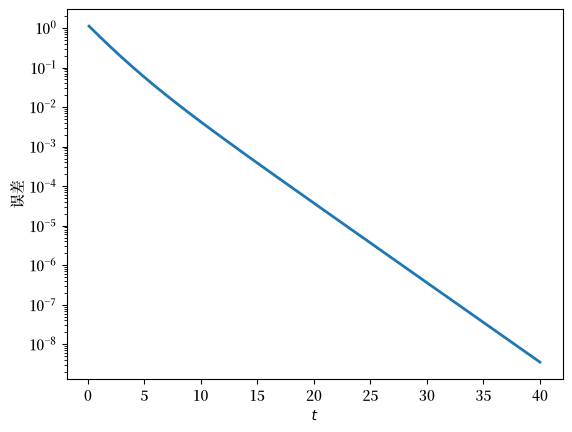

spectral gap = 0.462679


In [26]:
state_names = ["expansion", "normal", "contraction"]

U3 = np.array([[-0.40,  0.30,  0.10],
               [ 0.20, -0.50,  0.30],
               [ 0.10,  0.20, -0.30]])

r3 = np.array([0.06, 0.04, 0.01])
κ3 = np.zeros((3, 3))

A3 = build_generator(U3, r3, κ3)
ρ3, φ3 = principal_eigenpair(A3)
A3_hat = twisted_generator(A3, ρ3, φ3)
ς3 = stationary_distribution(A3_hat)

ψ = np.array([3.0, 1.0, 2.0])
limit = φ3 * np.sum((ψ / φ3) * ς3)

print("limit:")
for name, value in zip(state_names, limit):
    print(f"  {name:11s} {value:.6f}")

t_vals = np.linspace(0.1, 40, 300)
errors = np.array([
    np.max(np.abs(np.exp(-ρ3 * t_val) * expm(t_val * A3) @ ψ - limit))
    for t_val in t_vals
])

eigenvalues = eig(A3, right=False)
real_parts = np.sort(eigenvalues.real)[::-1]
gap = real_parts[0] - real_parts[1]

fig, ax = plt.subplots()
ax.semilogy(t_vals, errors, lw=2)
ax.set_xlabel("$t$")
ax.set_ylabel("误差")
plt.show()

print(f"spectral gap = {gap:.6f}")

归一化半群以由主特征值与其余特征值之间的分离所控制的指数率收敛。

在这个有限状态例子中，那个分离就是上面计算的谱隙。

```{solution-end}
```

```{exercise}
:label: lrr_ex_local_mg

从伊藤公式推导局部鞅约束 {eq}`eq:local-martingale-restriction`。

设 $M = \exp(A)$，其中 $A$ 是 {eq}`eq:additive-functional` 中的可加泛函，参数为 $(\beta,\gamma,\kappa)$。

1. 将 $A_t = A_t^c + A_t^j$ 分解为其连续部分和纯跳跃部分，并写出 $dA_t^c$ 和跳跃幅度 $\Delta A_t$。

2. 将半鞅的伊藤公式应用于 $f(a) = e^a$ 以证明

$$
    dM_t
    =
    M_{t-}\, dA_t^c
    + \tfrac{1}{2}\, M_{t-}\, d\langle A^c, A^c\rangle_t
    + M_{t-}\big(\exp[\Delta A_t] - 1\big)\quad\text{在跳跃处}.
$$

3. 使用 $d\langle A^c, A^c\rangle_t = \gamma^\top\gamma\, dt$ 并将跳跃项重写为对随机计数测度 $\zeta$ 的积分。

4. 将 $\zeta$ 分裂为其补偿子 $\eta(dy \mid X_{t-})\, dt$ 和被补偿鞅测度 $\tilde\zeta = \zeta - \eta(dy\mid X_{t-})\, dt$。

5. 收集漂移（可预测）项和鞅项，并得出结论：$M$ 是一个局部鞅当且仅当漂移在每个状态处消失，这给出 {eq}`eq:local-martingale-restriction`。
```

```{solution-start} lrr_ex_local_mg
:class: dropdown
```

这是一个解答。

*1.* 从参数化 {eq}`eq:additive-functional`，

$$
    dA_t^c = \beta(X_t)\, dt + \gamma(X_{t-})^\top\, dB_t,
    \qquad
    \Delta A_t = \kappa(X_t, X_{t-}) \text{ 在跳跃时刻}.
$$

*2.* 对 $f(a) = e^a$ 我们有 $f'(a) = f''(a) = e^a$，所以 $f'(A_{t-}) = f''(A_{t-}) = M_{t-}$。

半鞅的[（广义）伊藤公式](https://almostsuremath.com/2010/01/25/the-generalized-ito-formula/) 给出

$$
    dM_t
    =
    f'(A_{t-})\, dA_t^c
    + \tfrac{1}{2}\, f''(A_{t-})\, d\langle A^c, A^c\rangle_t
    + \big[f(A_t) - f(A_{t-})\big] .
$$

由于在跳跃处 $A_t = A_{t-} + \Delta A_t$，$f(A_t) - f(A_{t-}) = M_{t-}\big(\exp[\Delta A_t] - 1\big)$，这就是所述的表达式。

*3.* 代入 $d\langle A^c, A^c\rangle_t = \gamma(X_{t-})^\top \gamma(X_{t-})\, dt$ 并将跳跃贡献重写为对 $(X, A)$ 的随机计数测度 $\zeta$ 的积分给出

$$
\begin{aligned}
\frac{dM_t}{M_{t-}}
&=
\beta(X_t)\, dt
+ \gamma(X_{t-})^\top dB_t
+ \tfrac{1}{2}\,\gamma(X_{t-})^\top\gamma(X_{t-})\, dt
\\
&\quad
+ \int \big(\exp[\kappa(y, X_{t-})] - 1\big)\, \zeta(dy, dt) .
\end{aligned}
$$

*4.* 写 $\zeta = \tilde\zeta + \eta(dy\mid X_{t-})\, dt$ 将跳跃积分分离为一个鞅和一个可预测漂移贡献：

$$
\int \big(\exp[\kappa(y,X_{t-})] - 1\big)\zeta(dy,dt)
=
\int\big(\exp[\kappa(y,X_{t-})] - 1\big)\tilde\zeta(dy,dt)
+ \int\big(\exp[\kappa(y,X_{t-})] - 1\big)\eta(dy\mid X_{t-})\, dt .
$$

*5.* 收集漂移项和鞅项，

$$
\begin{aligned}
\frac{dM_t}{M_{t-}}
&=
\bigg[\beta(X_t)
+ \tfrac{1}{2}\gamma^\top\gamma
+ \int\big(\exp[\kappa(y,X_{t-})] - 1\big)\,\eta(dy\mid X_{t-})\bigg] dt
\\
&\quad
+ \gamma^\top dB_t
+ \int\big(\exp[\kappa(y,X_{t-})] - 1\big)\,\tilde\zeta(dy,dt) .
\end{aligned}
$$

布朗项和被补偿跳跃项是局部鞅，所以 $M$ 是一个局部鞅当且仅当括号中的漂移对每个状态 $x$ 消失，从而给出 {eq}`eq:local-martingale-restriction`。

```{solution-end}
```

```{exercise}
:label: lrr_ex4

推导扩展生成元在 {eq}`eq:extended-generator` 中的闭式表达式。

取马尔可夫状态在跳跃之间满足

$$
    dX_t^c = \xi(X_t)dt + \Gamma(X_t)dB_t
$$

的跳跃-扩散设定，其中 $\Sigma = \Gamma\Gamma^\top$ 且跳跃补偿子为 $\eta(dy \mid x)$。

设 $M = \exp(A)$，其中 $A$ 是 {eq}`eq:additive-functional` 中的可加泛函，并设 $\phi$ 是一个光滑的、严格正的函数。

回忆 {prf:ref}`lrr-def-extended-generator`，如果

$$
    N_t = M_t\phi(X_t) - \phi(X_0) - \int_0^t M_s \chi(X_s)\, ds
$$

是一个局部鞅，则 $\mathbb A\phi = \chi$。因此任务有两部分：识别 $M_t\phi(X_t)$ 的可预测漂移以读出候选 $\chi$，并验证残差 $N_t$ 确实是一个局部鞅。

(1) 将伊藤公式应用于跳跃之间的 $Y_t = \exp(A_t)\phi(X_t)$ 并证明 $dY_t$ 的连续部分具有漂移

$$
    M_t
    \left[
        (\xi + \Gamma\gamma)^\top
            \frac{\partial \phi}{\partial x}
        + \frac{1}{2}
          \operatorname{trace}\!\left(
              \Sigma \frac{\partial^2 \phi}{\partial x \partial x^\top}
          \right)
        + \left(\beta + \frac{\gamma^\top \gamma}{2}\right)\phi
    \right] dt .
$$

(2) 证明在一个跳跃时刻 $t$，$X_{t-}=x$ 和 $X_t=y$，

$$
    \Delta Y_t = M_{t-}\big[\exp[\kappa(y,x)]\phi(y) - \phi(x)\big] ,
$$

并得出可预测跳跃补偿子贡献漂移

$$
    M_{t-}
    \int
        \big\{
            \exp[\kappa(y,x)]\phi(y) - \phi(x)
        \big\}
        \eta(dy \mid x)\, dt .
$$

(3) 分解

$$
    \exp[\kappa(y,x)]\phi(y) - \phi(x)
    =
    \exp[\kappa(y,x)]
        \big[\phi(y) - \phi(x)\big]
    + \big[\exp[\kappa(y,x)] - 1\big]\phi(x),
$$

与 (1) 部分结合以获得完整的可预测漂移系数 $\chi(x)$，并检查它匹配闭式 {eq}`eq:extended-generator`。

(4) 将 (1) 部分的连续伊藤被积项识别为局部鞅 $N^c_t$，将 (2) 部分的被补偿跳跃和识别为局部鞅 $N^j_t$。

证明 $Y_t = M_t\phi(X_t)$ 的半鞅分解意味着

$$
    M_t\phi(X_t) - \phi(X_0) - \int_0^t M_s\, \chi(X_s)\, ds
    = N^c_t + N^j_t ,
$$

这是一个局部鞅。通过 {prf:ref}`lrr-def-extended-generator` 得出结论 $\mathbb A \phi = \chi$。
```

```{solution-start} lrr_ex4
:class: dropdown
```

这是一个解答：

*(1)* 设 $g(a, x) = e^a \phi(x)$，使得 $Y_t = g(A_t, X_t)$。

在跳跃之间，$A$ 和 $X$ 的连续部分是

$$
    dA_t^c = \beta(X_t)\, dt + \gamma(X_t)^\top dB_t,
    \qquad
    dX_t^c = \xi(X_t)\, dt + \Gamma(X_t)\, dB_t ,
$$

具有二次协变差

$$
    d\langle A^c, A^c\rangle_t = \gamma^\top \gamma\, dt,
    \qquad
    d\langle X^c, X^c\rangle_t = \Sigma\, dt,
    \qquad
    d\langle A^c, X^c\rangle_t = \Gamma\gamma\, dt .
$$

$g$ 的偏导数满足

$$
    \partial_a g = g,
    \quad
    \partial_{aa} g = g,
    \quad
    \partial_x g = e^a \frac{\partial \phi}{\partial x},
    \quad
    \partial_{ax} g = e^a \frac{\partial \phi}{\partial x},
    \quad
    \partial_{xx} g = e^a \frac{\partial^2 \phi}{\partial x \partial x^\top} .
$$

伊藤公式产生一个连续局部鞅 $N^c_t$（$dB_t$ 部分）加上漂移

$$
\begin{aligned}
    M_t \Big[
        \beta \phi
        + \tfrac{1}{2}\gamma^\top \gamma\, \phi
        + \xi^\top \tfrac{\partial \phi}{\partial x}
        + \tfrac{1}{2}\operatorname{trace}\!\big(\Sigma\, \tfrac{\partial^2 \phi}{\partial x \partial x^\top}\big)
        + (\Gamma\gamma)^\top \tfrac{\partial \phi}{\partial x}
    \Big]\, dt .
\end{aligned}
$$

将梯度项分组给出问题中的表达式。

*(2)* 在一个跳跃时刻 $t$，$\Delta A_t = \kappa(X_t, X_{t-}) = \kappa(y, x)$，所以 $M_t = M_{t-}\exp[\kappa(y,x)]$ 且

$$
    \Delta Y_t
    = M_t \phi(X_t) - M_{t-}\phi(X_{t-})
    = M_{t-}\big[\exp[\kappa(y,x)]\phi(y) - \phi(x)\big] .
$$

跳跃和减去其可预测补偿子是一个局部鞅 $N^j_t$，补偿子本身贡献问题中引用的可预测漂移。

*(3)* 将 (2) 中的跳跃漂移加到 (1) 中的连续漂移，$Y_t = M_t \phi(X_t)$ 在状态 $x$ 处的可预测漂移是 $M_t\, \chi(x)\, dt$，其中

$$
\begin{aligned}
    \chi(x)
    &=
    (\xi + \Gamma\gamma)^\top \frac{\partial \phi}{\partial x}
    + \frac{1}{2}\operatorname{trace}\!\left(
        \Sigma \frac{\partial^2 \phi}{\partial x \partial x^\top}
      \right)
    + \left(\beta + \frac{\gamma^\top \gamma}{2}\right)\phi(x)
    \\
    &\quad
    + \int \exp[\kappa(y,x)]\big[\phi(y) - \phi(x)\big]\, \eta(dy \mid x)
    + \phi(x)\int \big[\exp[\kappa(y,x)] - 1\big]\, \eta(dy \mid x) .
\end{aligned}
$$

收集乘以 $\phi(x)$ 的项可恢复 {eq}`eq:extended-generator`。

*(4)* 将两个鞅部分放在一起并对漂移积分，步骤 (1) 和 (2) 给出半鞅分解

$$
    M_t \phi(X_t)
    =
    \phi(X_0)
    + \int_0^t M_s\, \chi(X_s)\, ds
    + N^c_t + N^j_t .
$$

重新排列，

$$
    N_t
    :=
    M_t \phi(X_t) - \phi(X_0) - \int_0^t M_s\, \chi(X_s)\, ds
    = N^c_t + N^j_t ,
$$

这是一个局部鞅，因为它是局部鞅之和。

这恰好是 {prf:ref}`lrr-def-extended-generator` 所要求的性质，所以 $\chi = \mathbb A \phi$。

```{solution-end}
```